In [2]:
import pandas as pd
import os 
import numpy as np
import json
import random
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import matplotlib.cm as cm
from matplotlib.patches import Patch
from scipy.stats import spearmanr, pearsonr, linregress
from src.setting import ExcludSubj, GetInfo, get_data_grp
from src.decomposition import CompoThr
from sklearn.decomposition import PCA
from src.config import OUT_PATH, PROJECT_PATH, color_event
from src.behavior import extract_RT
from scipy.ndimage import gaussian_filter1d
from statsmodels.stats.multitest import multipletests
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple

dataset_label = '_mf70-160'
path_behavior=PROJECT_PATH + '/misc/events'
path_class = PROJECT_PATH + '/misc/concat_beh_data.csv'

epoch_path = OUT_PATH + '/Data_longWOBS' + dataset_label

subj_included = [file.replace('_epochs.p', '') for file in os.listdir(epoch_path) if file[-len('epochs.p'):] == 'epochs.p']

subj_included = ExcludSubj(subj_included=subj_included, data_path=epoch_path)

nb_trials = 16
subj_included_restricted = {16: ['BJH072', 'LL36', 'BJH069', 'SLCH020', 'BJH045', 'LL14', 'BJH050',
       'BJH027', 'OS70', 'BJH052', 'OS61', 'BJH041', 'BJH046', 'BJH056',
       'LL31', 'BJH039', 'BJH042', 'BJH026', 'LL08', 'BJH029',
       'DA037', 'BJH058', 'SLCH024', 'BJH049']}

to_exclude = [] #['SLCH018']
for ex in to_exclude :
    subj_included.remove(ex)

path = epoch_path + f'/{subj_included[0]}_info.json'
with open(path) as json_data:
    d = json.load(json_data)
    time_epoch = d['time_epoch']
    time_tfr=d['time_tfr']

titles = ["Memorized", "Novel"]

In [3]:
df_RT = extract_RT(subj_included=subj_included, path_behavior=path_behavior, path_info=epoch_path)

## SUBJ PB

In [4]:
df_RT[df_RT['RT'] < 3*0.360].head(50)

,recognition_onset,keypress_onset,RT,subject,ev_id


In [5]:
df_RT[df_RT['RT'] > 7].head(50)

,recognition_onset,keypress_onset,RT,subject,ev_id


In [5]:
df_RT[df_RT['RT'].isna()]

,recognition_onset,keypress_onset,RT,subject,ev_id


In [6]:
suj = 'SLCH018'
info_file = epoch_path + f'/{suj}_info.json'
with open(info_file) as f:
    info = json.load(f)
    events = info['event_id']
coord, areas, elect_list, subj_list, region = GetInfo([suj], data_path=epoch_path)

In [7]:
df = pd.read_csv(path_behavior + f'/{suj}_events.csv')
df[df['task']=='learning_bach'][50:100].head(50)

,subject,task,onset,code,type
50,SLCH018,learning_bach,275.820,50,KeyPress
51,SLCH018,learning_bach,278.900,10,recognition
52,SLCH018,learning_bach,281.988,49,KeyPress
53,SLCH018,learning_bach,284.100,20,recognition
54,SLCH018,learning_bach,286.660,50,KeyPress
55,SLCH018,learning_bach,289.200,20,recognition
56,SLCH018,learning_bach,291.699,50,KeyPress
57,SLCH018,learning_bach,294.300,20,recognition
58,SLCH018,learning_bach,296.692,50,KeyPress
59,SLCH018,learning_bach,299.400,10,recognition


## General behavior overview

/tmp/ipykernel_5322/1971638642.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax[1].boxplot(data,labels=conditions,patch_artist=True,showfliers=True)


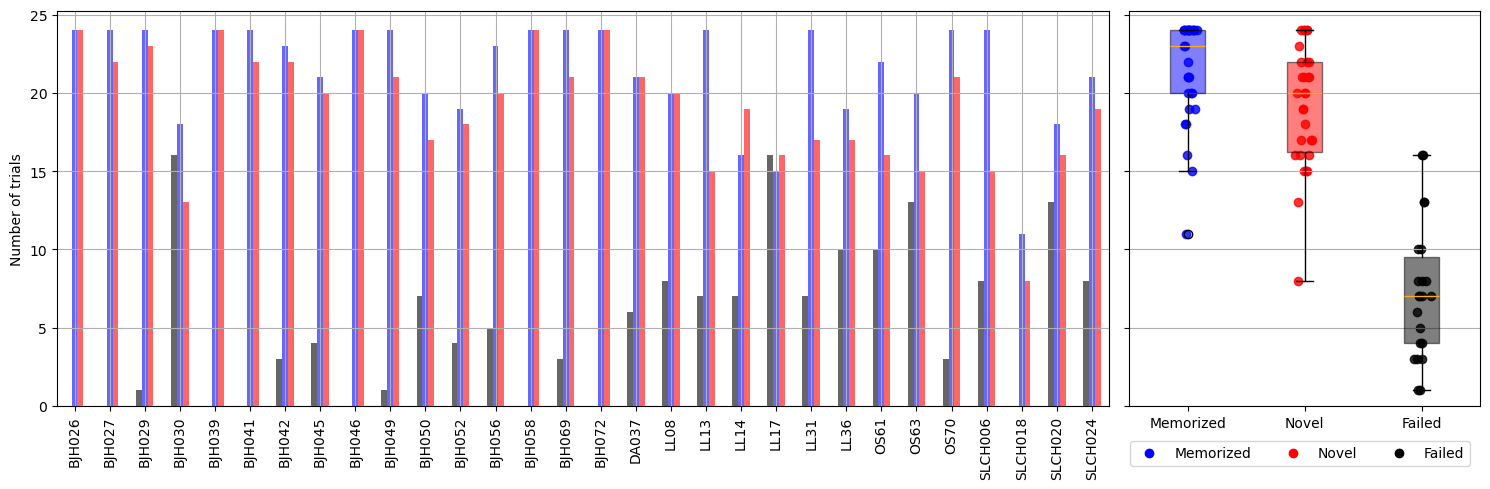

In [5]:
df = df_RT.copy()
df["ev_id"] = df["ev_id"].astype(str)
df["cond"] = df["ev_id"]
df.loc[df["cond"] == "1", "cond"] = "Memorized"
df.loc[df["cond"] == "2", "cond"] = "Novel"
df.loc[df["cond"].isin(['101','102','201','202']), "cond"] = "Failed"
trial_counts = (df.groupby(["subject", "cond"]).size().reset_index(name="n_trials"))
pivot_counts = trial_counts.pivot(index="subject",columns="cond",values="n_trials").fillna(0)

fig, ax=plt.subplots(1, 2, width_ratios=[3/4, 1/4], figsize=(15, 5), sharey=True)
colors = {'Memorized': 'b', 'Novel': 'r', 'Failed': 'k'}
pivot_counts.plot(kind="bar", color=colors,alpha = 0.6, ax=ax[0])
# Custom legencna d
legend_handles = [Patch(facecolor='b', alpha=0.6, label='Memorized'),Patch(facecolor='r', alpha=0.6, label='Novel'),Patch(facecolor='k', alpha=0.6, label='Failed')]

ax[0].legend(handles=legend_handles, title="Trial type")
ax[0].set_ylabel("Number of trials")
ax[0].set_xlabel("")
ax[0].grid()

conditions = ['Memorized', 'Novel', 'Failed']

data = [trial_counts.loc[trial_counts['cond'] == c, 'n_trials'] for c in conditions]
bp = ax[1].boxplot(data,labels=conditions,patch_artist=True,showfliers=True)
for patch, cond in zip(bp['boxes'], conditions):
    patch.set_facecolor(colors[cond])
    patch.set_alpha(0.5)

for i, cond in enumerate(conditions, start=1):
    y = trial_counts.loc[trial_counts['cond'] == cond, 'n_trials']
    x = np.random.normal(i, 0.04, len(y))  # jitter
    ax[1].scatter(x, y, color=colors[cond], alpha=0.8)

ax[1].set_ylabel("Number of trials")
ax[1].grid(axis='y')


handles = [Line2D([0], [0], marker='o', linestyle='', color=color_event[0],label='Memorized', markersize=6),
                Line2D([0], [0], marker='o', linestyle='', color=color_event[1], label='Novel', markersize=6),
                Line2D([0], [0], marker='o', linestyle='', color='k', label='Failed', markersize=6)]

for a in ax:
    leg = a.get_legend()
    if leg is not None:
        leg.remove()

fig.legend(handles=handles,
           labels=['Memorized', 'Novel', 'Failed'],
           loc='upper center',
           ncol=3,
           frameon=True,
           bbox_to_anchor=(0.87, 0.12))


plt.tight_layout()

In [6]:
df['success'] = df['ev_id'].map({'1':1, '2':1, '101':0, '102':0, '201':0, '202':0})
df['cond'] = df['ev_id'].map({'1':'Memorized', '2':'Novel', '101':'Memorized', '102':'Memorized', '201':'Novel', '202':'Novel'})
df.to_csv(OUT_PATH+ '/Behavior_mf70-160/behavG.csv')


### Some basic stats


In [7]:
import statsmodels.formula.api as smf
from scipy.special import expit
from scipy.stats import norm

def accuracy_above_chance_glmm(df,participant_col="subject",accuracy_col="success"):
    """
    Test whether trial-level accuracy is above chance (50%)
    using a binomial mixed-effects model with a random intercept
    for participant.

    Returns:
        dict containing:
        - estimated accuracy
        - odds ratio
        - 95% CI for OR
        - z statistic
        - p value for accuracy > 50%
    """

    data = df[[participant_col, accuracy_col]].dropna().copy()
    data[accuracy_col] = data[accuracy_col].astype(int)

    # Binomial mixed-effects model
    model = smf.mixedlm(f"{accuracy_col} ~ 1",data=data,groups=data[participant_col])

    # statsmodels MixedLM is Gaussian, so it cannot fit a binomial model.
    # Therefore, use BinomialBayesMixedGLM for the binomial mixed model.
    from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM

    variance_component = {"participant": f"0 + C({participant_col})"}
    model = BinomialBayesMixedGLM.from_formula(f"{accuracy_col} ~ 1",variance_component,data)
    result = model.fit_vb()
    beta = result.fe_mean[0]
    se = result.fe_sd[0]
    estimated_accuracy = expit(beta)
    OR = np.exp(beta)
    lower_beta = beta - 1.96 * se
    upper_beta = beta + 1.96 * se
    OR_lower = np.exp(lower_beta)
    OR_upper = np.exp(upper_beta)
    # Wald test beta = 0, p = 0.50
    z = beta / se
    # One-sided test: accuracy > 50%
    p_one_sided = 1 - norm.cdf(z)

    return {"accuracy": estimated_accuracy,
        "OR": OR,
        "OR_95CI_lower": OR_lower,
        "OR_95CI_upper": OR_upper,
        "z": z,
        "p_one_sided": p_one_sided,
        "model": result}

def accuracy_by_condition_glmm(df,participant_col="subject",condition_col="cond",accuracy_col="success"):
    """
    Compare trial-level accuracy between Memorized and Novel
    conditions using a binomial mixed-effects model with a
    participant random intercept.

    Memorized is used as the reference condition.

    Returns:
        dict containing:
        - Novel vs Memorized OR
        - 95% CI
        - z statistic
        - p value
        - model result
    """

    data = df[[participant_col, condition_col, accuracy_col]].dropna().copy()
    data[accuracy_col] = data[accuracy_col].astype(int)
    data[condition_col] = pd.Categorical(data[condition_col],categories=["Memorized", "Novel"])

    from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM
    variance_component = {"participant": f"0 + C({participant_col})"}
    model = BinomialBayesMixedGLM.from_formula(f"{accuracy_col} ~ C({condition_col})",variance_component,data)
    result = model.fit_vb()
    beta = result.fe_mean[1]
    se = result.fe_sd[1]
    OR = np.exp(beta)
    lower_beta = beta - 1.96 * se
    upper_beta = beta + 1.96 * se

    OR_lower = np.exp(lower_beta)
    OR_upper = np.exp(upper_beta)

    z = beta / se
    p = 2 * (1 - norm.cdf(abs(z)))

    return {
        "Novel_vs_Memorized_OR": OR,
        "OR_95CI_lower": OR_lower,
        "OR_95CI_upper": OR_upper,
        "z": z,
        "p": p,
        "model": result
    }

def reaction_time_lmm(
    df,
    participant_col="subject",
    rt_col="RT",
    condition_col="cond", 
    success_col="success"
):
    """
    Compare reaction time between two conditions using a
    linear mixed-effects model with a random intercept for participant.

    Returns:
        dict containing:
        - mean RT per condition
        - condition effect (difference in RT)
        - 95% CI for condition effect
        - z/t statistic
        - p value
        - model
    """
    data = df[(df[success_col] == 1) &(df[rt_col].notna())].copy()

    data = data[ [participant_col, rt_col, condition_col]].dropna().copy()
    data[rt_col] = pd.to_numeric(data[rt_col], errors="coerce")
    data = data.dropna(subset=[rt_col])
    data[condition_col] = data[condition_col].astype("category")

    # Linear mixed-effects model
    model = smf.mixedlm(
        f"{rt_col} ~ C({condition_col})",
        data=data,
        groups=data[participant_col]
    )

    result = model.fit()

    # Estimated means per condition
    condition_means = data.groupby(
        condition_col,
        observed=True
    )[rt_col].mean().to_dict()

    # Fixed-effect parameters
    params = result.fe_params
    pvalues = result.pvalues
    conf_int = result.conf_int()

    return {
        "condition_means": condition_means,
        "fixed_effects": params,
        "95CI": conf_int,
        "p_values": pvalues,
        "model": result
    }

In [8]:
accuracy_above_chance_glmm(df)

{'accuracy': np.float64(0.9255659211407691),
 'OR': np.float64(12.43470645873364),
 'OR_95CI_lower': np.float64(10.462707648338847),
 'OR_95CI_upper': np.float64(14.778385281502272),
 'z': np.float64(28.609737963955116),
 'p_one_sided': np.float64(0.0),
 'model': <statsmodels.genmod.bayes_mixed_glm.BayesMixedGLMResults at 0x7ff92b714310>}

In [9]:
accuracy_by_condition_glmm(df)

{'Novel_vs_Memorized_OR': np.float64(3.884615126812436),
 'OR_95CI_lower': np.float64(2.669981069635416),
 'OR_95CI_upper': np.float64(5.651813361178833),
 'z': np.float64(7.093609603753746),
 'p': np.float64(1.3065104553788842e-12),
 'model': <statsmodels.genmod.bayes_mixed_glm.BayesMixedGLMResults at 0x7ff92b359720>}

In [10]:
reaction_time_lmm(df)

{'condition_means': {'Memorized': 2.71038736877916,
  'Novel': 2.7356260752395456},
 'fixed_effects': Intercept           2.728674
 C(cond)[T.Novel]    0.015252
 dtype: float64,
 '95CI':                          0         1
 Intercept         2.573821  2.883528
 C(cond)[T.Novel] -0.039858  0.070363
 Group Var         0.339582  1.135485,
 'p_values': Intercept           2.271918e-261
 C(cond)[T.Novel]     5.875153e-01
 Group Var            2.807435e-04
 dtype: float64,
 'model': <statsmodels.regression.mixed_linear_model.MixedLMResultsWrapper at 0x7ff92b355210>}

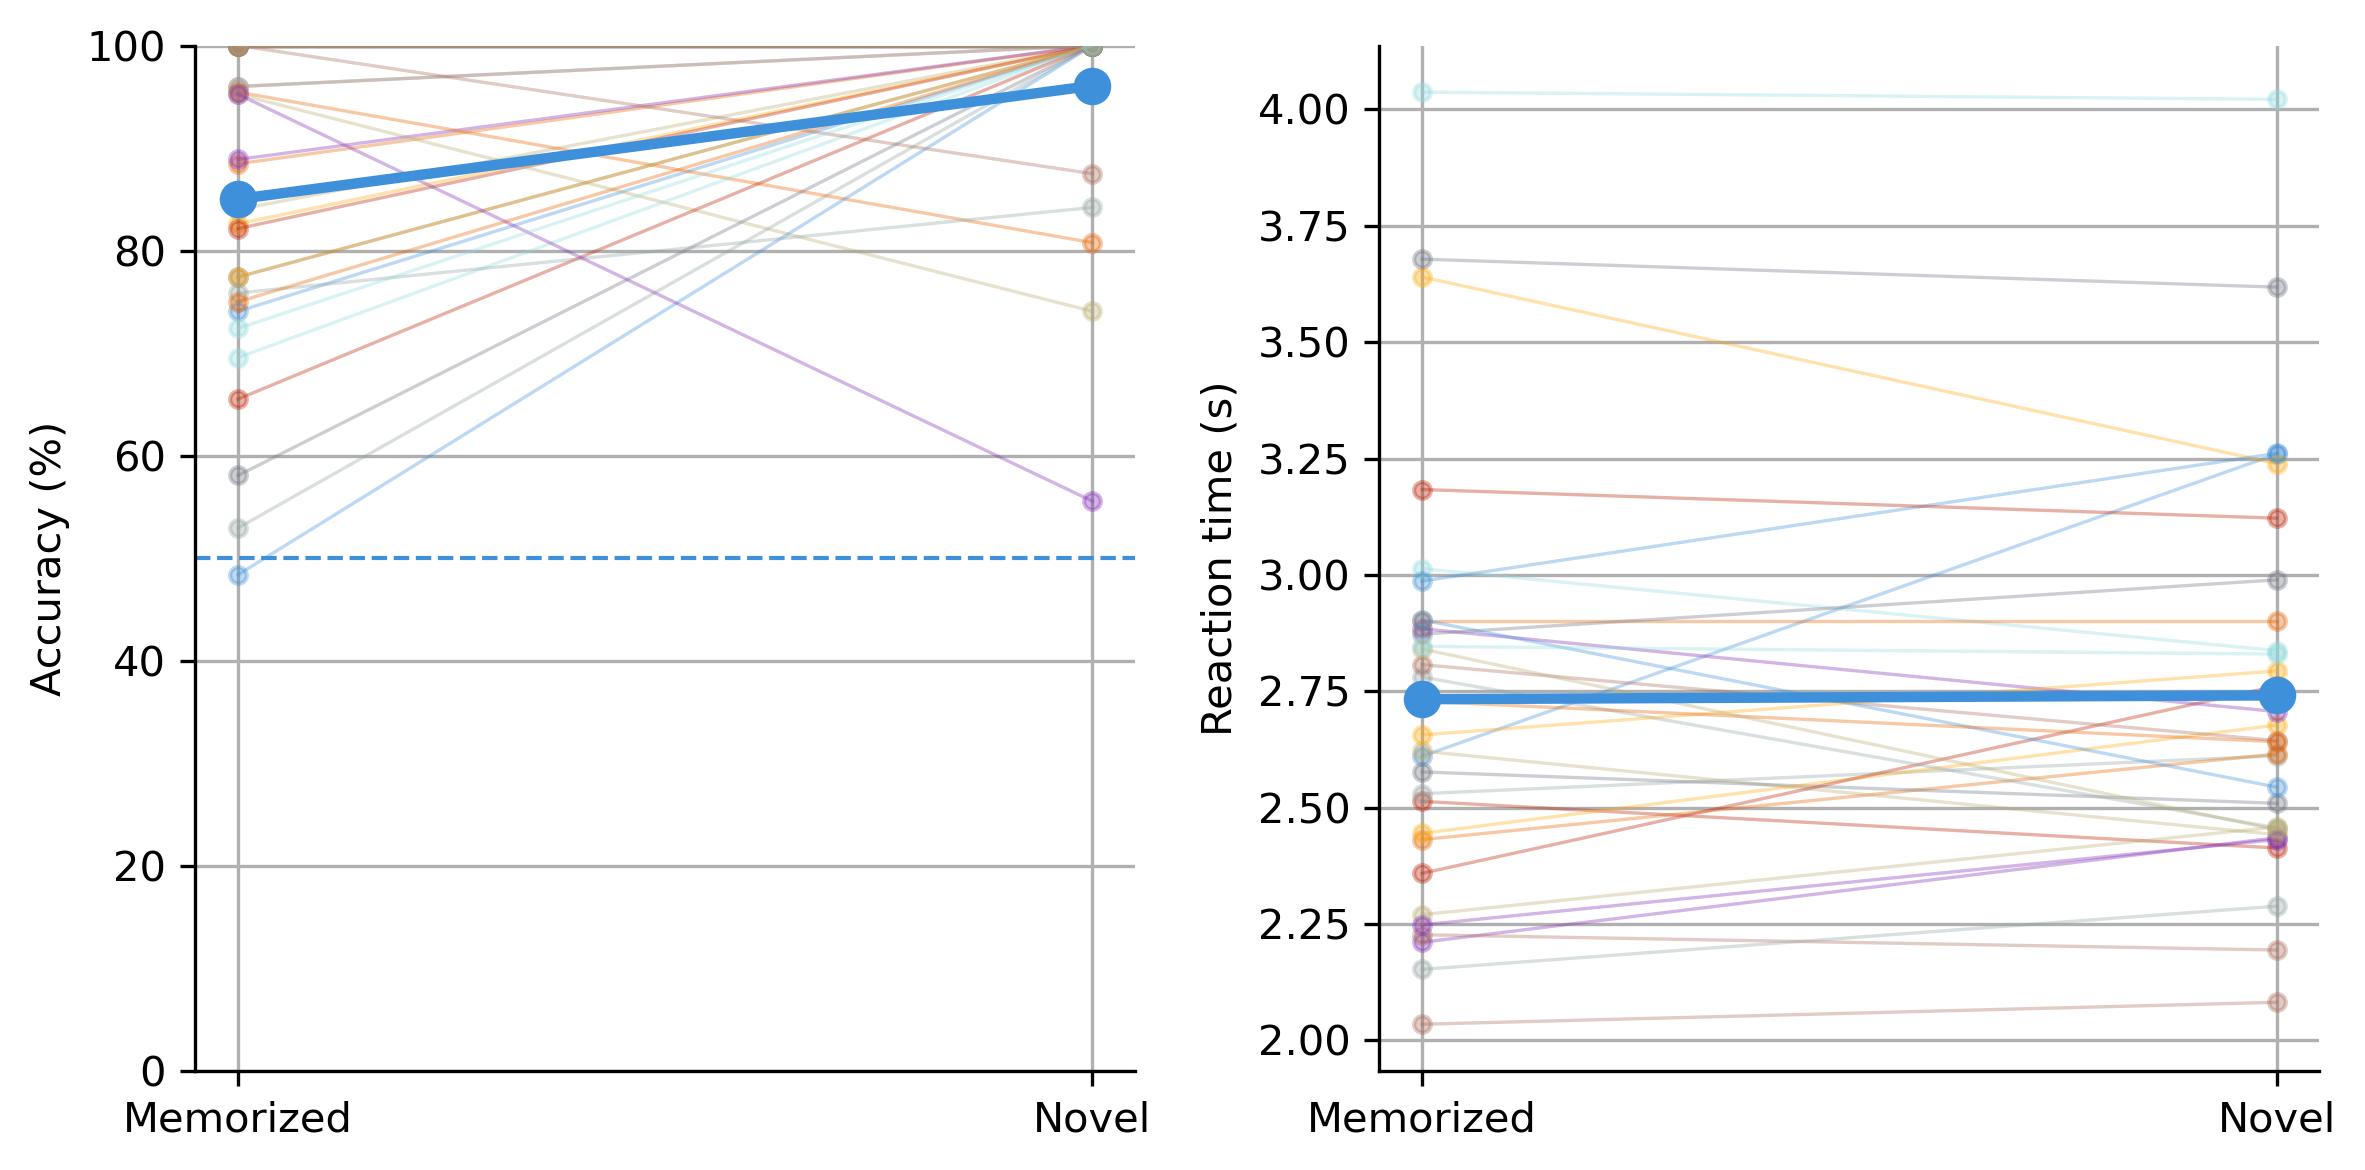

In [11]:
accuracy_data = (df.groupby(["subject", "cond"])["success"].mean().reset_index())
rt_data = df[(df["success"] == 1) &(df["RT"].notna())].copy()
rt_data = (rt_data.groupby(["subject", "cond"])["RT"].mean().reset_index())
condition_order = ["Memorized", "Novel"]
accuracy_data["cond"] = pd.Categorical(accuracy_data["cond"],categories=condition_order,ordered=True)
rt_data["cond"] = pd.Categorical(rt_data["cond"],categories=condition_order,ordered=True)
fig, axes = plt.subplots(1, 2,figsize=(8, 4),dpi=300)
ax = axes[0]
for subject in accuracy_data["subject"].unique():
    subject_data = accuracy_data[accuracy_data["subject"] == subject].sort_values("cond")
    ax.plot(range(len(subject_data)),subject_data["success"] * 100,marker="o",markersize=4,linewidth=0.8, alpha=0.35)

means = (accuracy_data.groupby("cond", observed=True)["success"].mean().reindex(condition_order))
ax.plot(range(len(means)),means * 100,marker="o",markersize=8,linewidth=2.5)
ax.set_xticks(range(len(condition_order)))
ax.set_xticklabels(condition_order)
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 100)
ax.axhline(50,linestyle="--",linewidth=1)

ax = axes[1]
for subject in rt_data["subject"].unique():
    subject_data = rt_data[rt_data["subject"] == subject].sort_values("cond")
    ax.plot(range(len(subject_data)),subject_data["RT"],marker="o",markersize=4,linewidth=0.8,alpha=0.35)

means_rt = (rt_data.groupby("cond", observed=True)["RT"].mean().reindex(condition_order))
ax.plot(range(len(means_rt)),means_rt,marker="o",markersize=8,linewidth=2.5)
ax.set_xticks(range(len(condition_order)))
ax.set_xticklabels(condition_order)
ax.set_ylabel("Reaction time (s)")

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both",which="major",labelsize=10)
    ax.grid()

plt.tight_layout()
plt.show()

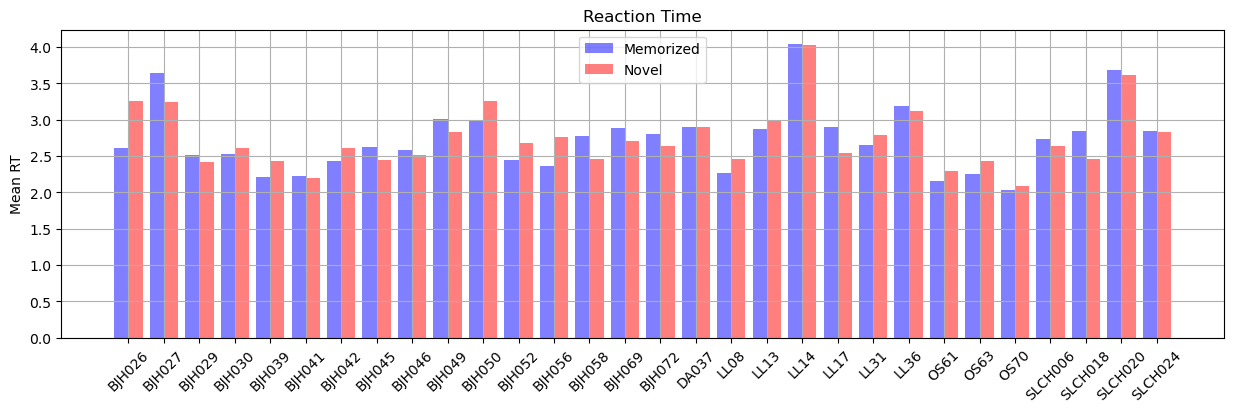

In [12]:
fig, ax = plt.subplots(figsize=(15, 4))

rt = (
    df_RT[df_RT['ev_id'].isin(['1', '2'])]
    .groupby(['subject', 'ev_id'])['RT']
    .mean()
    .unstack()
)

x = np.arange(len(rt.index))
width = 0.4

ax.bar(x - width/2, rt['1'], width, label='Memorized', color='b', alpha =0.5)
ax.bar(x + width/2, rt['2'], width, label='Novel', color='r', alpha = 0.5)

ax.set_xticks(x)
ax.set_xticklabels(rt.index, rotation=45)
ax.set_ylabel('Mean RT')
ax.set_title('Reaction Time')
ax.legend()
ax.grid()

In [13]:
# normalize group
df_RT["RT_z"] = (df_RT["RT"] - df_RT["RT"].mean()) / df_RT["RT"].std()

# normalize per subject
df_RT['RT_norm_subj'] = df_RT.groupby("subject")["RT"].transform(lambda x: (x - x.mean()) / x.std())

,mean,std,median,count
ev_id,,,,
1,2.710387,6.531179e-01,2.536000,643
101,3.130529,7.202760e-01,3.012000,47
102,2.935454,6.212564e-01,2.837891,83
2,2.735626,6.114395e-01,2.593000,574
201,2.900000,4.689738e-14,2.900000,11
202,2.900000,4.282398e-14,2.900000,19


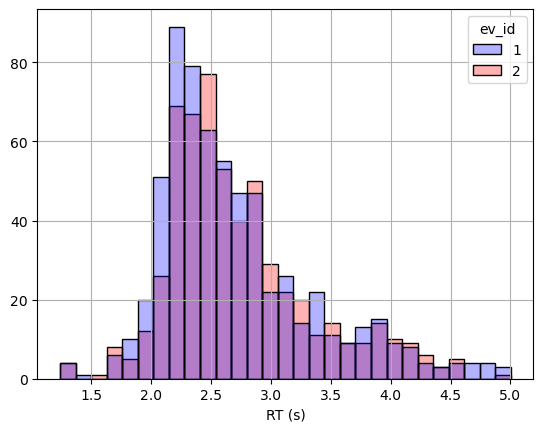

In [14]:
RT_type = 'RT'
df_RT["RT_category"] = pd.qcut(df_RT[RT_type],q=3,labels=["Slow","Medium", "Fast"])
df_RT[RT_type].quantile([0.33, 0.67]).values
df_RT =df_RT.reset_index(drop=True)


fig, ax = plt.subplots()
sns.histplot(df_RT[df_RT['ev_id'].isin(['1', '2'])], x=RT_type, hue='ev_id', ax=ax, palette={'1':'b', '2':'r'}, alpha = 0.3)
#ax.vlines(x=df_RT[RT_type].quantile([0.33, 0.67]).values, ymin=0, ymax=100, colors='k')
ax.grid()
ax.set_ylabel('')
ax.set_xlabel('RT (s)')
df_RT.groupby("ev_id")[RT_type].agg(["mean", "std", "median", "count"])

## Subject level

In [13]:
# trials :
tr0 = {'Slow': [], 'Medium':[], 'Fast':[]}
tr1 = {'Slow': [], 'Medium':[], 'Fast':[]}

for subj in subj_included : 
    
    file = epoch_path + f'/{subj}_TFRtrials.p'
    with open(file, "rb") as f:
        TFRtr = pickle.load(f)[:, :, -1, :]

    for speed in ['Slow','Medium', 'Fast']:
        df = df_RT[(df_RT['subject'] == subj)].reset_index()
        id_speed = np.where(df[df_RT['ev_id'] == '1'].RT_category == speed)[0]
        tr0[speed].append(TFRtr[id_speed, :, :])
        id_speed = np.where(df[df_RT['ev_id'] == '2'].RT_category == speed)[0]
        tr1[speed].append(TFRtr[id_speed, :, :])

/tmp/ipykernel_32431/1094587115.py:13: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  id_speed = np.where(df[df_RT['ev_id'] == '1'].RT_category == speed)[0]
/tmp/ipykernel_32431/1094587115.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  id_speed = np.where(df[df_RT['ev_id'] == '2'].RT_category == speed)[0]
/tmp/ipykernel_32431/1094587115.py:13: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  id_speed = np.where(df[df_RT['ev_id'] == '1'].RT_category == speed)[0]
/tmp/ipykernel_32431/1094587115.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  id_speed = np.where(df[df_RT['ev_id'] == '2'].RT_category == speed)[0]
/tmp/ipykernel_32431/1094587115.py:13: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  id_speed = np.where(df[df_RT['ev_id'] == '1'].RT_category == speed)[0]
/tmp/ipykernel_32431/1094587115.py:15: UserWarning: Boolean 

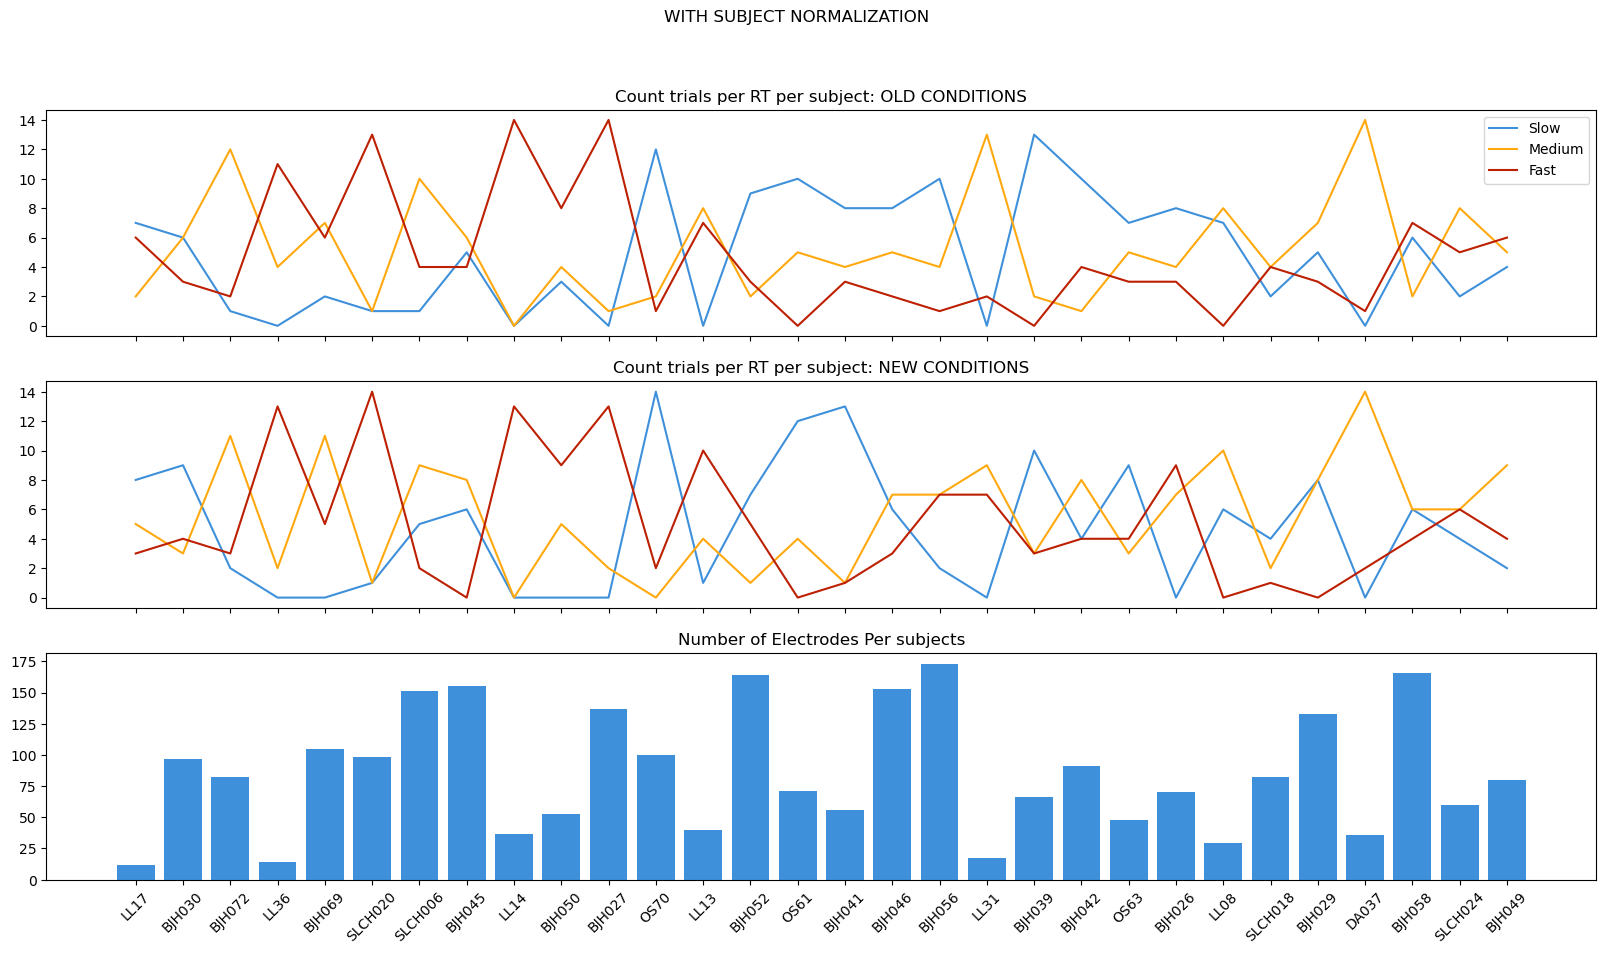

In [14]:
count = {}
fig, ax=plt.subplots(3, 1, figsize=(20, 10), sharex=True)
fig.suptitle('WITH SUBJECT NORMALIZATION')
for s in ['Slow', 'Medium', 'Fast'] : 
    count[s] = []
    for tr in tr0[s] : 
        count[s].append(tr.shape[0])
    ax[0].plot(subj_included, count[s], label =s)
    
    count[s] = []
    for tr in tr1[s] : 
        count[s].append(tr.shape[0])
    ax[1].plot(subj_included, count[s], label =s)

elect_count =[]
for tr in tr1[s]:
    elect_count.append(tr.shape[1])
ax[2].bar(subj_included,elect_count)

ax[0].set_title('Count trials per RT per subject: OLD CONDITIONS')
ax[1].set_title('Count trials per RT per subject: NEW CONDITIONS')
ax[2].set_title('Number of Electrodes Per subjects')
ax[2].tick_params(axis='x', rotation=45)

ax[0].legend()

## supsubj level

In [15]:
pc_use = 0
pca = PCA(pc_use+1)

nb_trials = 16
sorted_='RT'
corr = np.zeros((2, len(time_tfr)))
pval = np.zeros((2, len(time_tfr)))
rt_mean_all = np.zeros((2, nb_trials))

data_grp = get_data_grp(subj_included_restricted[nb_trials], return_subj=False, data_path=epoch_path, polarity_cor=(False,0), type_data='tfr')[:, :, -1, :]
pca_transform =  pca.fit_transform(np.concat([data_grp[0, :,:], data_grp[1, :, :]], axis=-1).T)[:, pc_use]

dataset0=[]
dataset1 = []

# subset of each 
supsubj = {0 :[], 1: []}
full_dataset = {0 :[], 1: []}

for ic, condi in enumerate(['1', '2'] ): 
    rt_subj = []
    for subj in subj_included_restricted[nb_trials]:
        df = df_RT[(df_RT['subject'] == subj)].reset_index(drop=True)
        df= df.dropna()
        if len(df) <4 : 
            print(subj)
        rt_condi=df[df['ev_id'] == condi].reset_index()[['RT', 'index']]

        if len(rt_condi) > nb_trials : # if the there are more than 16 trials 
            rt_condi = rt_condi.sample(n=nb_trials, random_state=None)
        else : 
            rt_condi = rt_condi.sample(n=nb_trials, replace=True)

        rt_condi_sorted = rt_condi.sort_values(by = sorted_).reset_index(drop=True)

        file = epoch_path + f'/{subj}_TFRtrials.p'
        with open(file, "rb") as f:
            TFRtr = pickle.load(f)[:, :, -1, :]
        random_index = rt_condi_sorted.loc[:, 'index'].values
        supsubj[ic].append(TFRtr[random_index,:,:])
        rt_subj.append(df.loc[random_index, 'RT'])
    rt_mean_all[ic, :] = np.concat([r.values[None, :] for r in rt_subj], axis=0).mean(0)
 
dataset0 = np.concat(supsubj[0], axis=1)
dataset1 = np.concat(supsubj[1], axis=1)

transform0 = np.zeros((nb_trials,  len(time_tfr)))
transform1 = np.zeros((nb_trials,  len(time_tfr)))

for tr in range(nb_trials) : 
    transform0[tr, :] = dataset0[tr, :, :].T @ pca.components_[pc_use, :]
    transform1[tr, :] = dataset1[tr, :, :].T @ pca.components_[pc_use, :]

# corr with the RT
for t in range( len(time_tfr)) : 
    if ic in range(2):
        corr[ic, t], pval[ic, t] = spearmanr(transform0[:, t], rt_mean_all[ic, :]) 



In [16]:
out_path = OUT_PATH + '/Behavior'
if not os.path.exists(out_path) : 
    os.makedirs(out_path)
    
with open(out_path + f"/mean_rt_supsubj.pkl", "wb") as f:
    pickle.dump(rt_mean_all, f)

/tmp/ipykernel_32431/2891613802.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(subj_included + ['supersubject'])


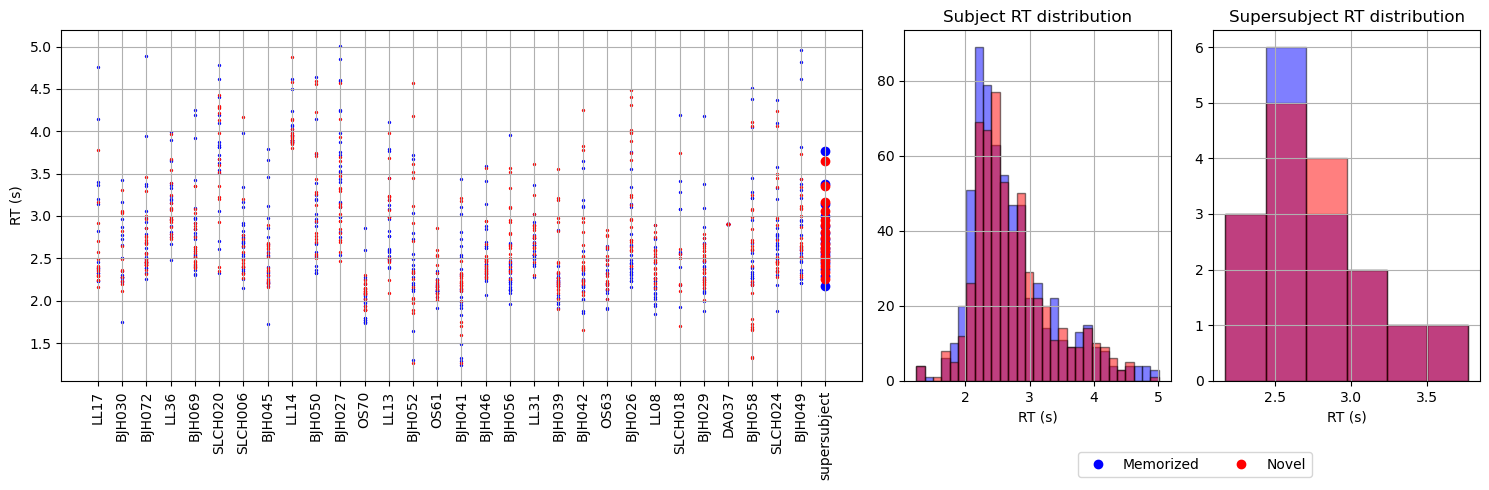

In [17]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), width_ratios=[6/10, 2/10, 2/10])
rt=[]
ax=axs[0]
for isub, subj in enumerate(subj_included) : 
    if isub==0 :
        ax.scatter(x=[subj] * len(df_RT[(df_RT['subject'] == subj) & (df_RT['ev_id'] == '1')].RT) , y=df_RT[(df_RT['subject'] == subj) & (df_RT['ev_id'] == '1')].RT, s=2, c=color_event[0], label =titles[0])
        ax.scatter(x=[subj] * len(df_RT[(df_RT['subject'] == subj) & (df_RT['ev_id'] == '2')].RT,) , y=df_RT[(df_RT['subject'] == subj) & (df_RT['ev_id'] == '2')].RT, s=2, c=color_event[1], label=titles[1])
    else : 
        ax.scatter(x=[subj] * len(df_RT[(df_RT['subject'] == subj) & (df_RT['ev_id'] == '1')].RT) , y=df_RT[(df_RT['subject'] == subj) & (df_RT['ev_id'] == '1')].RT, s=2, c=color_event[0])
        ax.scatter(x=[subj] * len(df_RT[(df_RT['subject'] == subj) & (df_RT['ev_id'] == '2')].RT,) , y=df_RT[(df_RT['subject'] == subj) & (df_RT['ev_id'] == '2')].RT, s=2, c=color_event[1])
ax.scatter(x=['supersubject']*nb_trials, y=rt_mean_all[0, :], c='b')
ax.scatter(x=['supersubject']*nb_trials, y=rt_mean_all[1, :], c='r')
ax.tick_params(axis='x', rotation=90)
ax.set_xticklabels(subj_included + ['supersubject'])
ax.set_ylabel('RT (s)')
ax.legend(title='', bbox_to_anchor=(1, 1))
ax.grid()

ax=axs[1:]
RT_type = 'RT'
df_rt_all = pd.DataFrame(rt_mean_all.flatten(), columns=['RT'])
df_rt_all['Events'] = ['Memorized'] * nb_trials + ['Novel'] * nb_trials

bins0 = np.histogram_bin_edges(df_RT[df_RT['ev_id'].isin(['1', '2'])][RT_type], bins='auto')
bins1 = np.histogram_bin_edges(df_rt_all['RT'], bins='auto')

for i, ev in enumerate(['1', '2']):
    data = df_RT.loc[df_RT['ev_id'] == ev, RT_type]
    ax[0].hist(data,bins=bins0,alpha=0.5,color=color_event[i],label='Memorized' if ev == '1' else 'Novel', edgecolor='black')

for i, ev in enumerate(['Memorized', 'Novel']):
    data = df_rt_all.loc[df_rt_all['Events'] == ev, 'RT']
    ax[1].hist(data,bins=bins1,alpha=0.5,color=color_event[i],label=ev, edgecolor='black',)

leg = ax[0].get_legend()
if leg is not None:
    leg.remove()

leg = ax[1].legend(frameon=False)
leg.set_title(None)

for a in ax:
    a.set_xlabel('RT (s)')
    a.set_ylabel('')
    a.grid(True)

ax[0].set_title('Subject RT distribution')
ax[1].set_title('Supersubject RT distribution')


handles = [Line2D([0], [0], marker='o', linestyle='', color=color_event[0],label='Memorized', markersize=6),Line2D([0], [0], marker='o', linestyle='', color=color_event[1], label='Novel', markersize=6)]

for a in axs:
    leg = a.get_legend()
    if leg is not None:
        leg.remove()

fig.legend(handles=handles,
           labels=['Memorized', 'Novel'],
           loc='upper center',
           ncol=2,
           frameon=True,
           bbox_to_anchor=(0.8, 0.1))

plt.tight_layout()

- The non-permuted distribution captures the sampling variability caused by trial selection
- The permuted distribution represents the null distribution.

## Specific time points

In [6]:
from src.behavior import get_cross_point, get_slop_pc2, area_pc2, get_slop_pc3

find_tp = {'0_pc1': lambda x, tr : get_cross_point(tr, x, tstart=90, tend=150), 
           '0_pc2': lambda x, tr :  get_cross_point(tr, x, tstart=60, tend=150), 
           '0_pc3': lambda x, tr : get_cross_point(tr, x, tstart=120, tend=140), 
           'min_pc2': lambda x, tr : np.argmax(x[tr, 100:]) + 100, 
           'bump_pc3' : lambda x, tr : 115 + np.argmax(x[tr, 115:]),
           'desc_slop_pc2': lambda x, tr : get_slop_pc2(tr, x, time=time_tfr)[0] , 
           'asc_slop_pc2' : lambda x, tr : get_slop_pc2(tr, x, time=time_tfr)[1], 
           'slop_pc3': lambda x, tr : get_slop_pc3(tr, x, time=time_tfr),
           'area_under_pc2': lambda x, tr : area_pc2(tr, x)[0], 
           'area_above_pc2': lambda x, tr : area_pc2(tr, x)[1]}

In [7]:
name_tp = {'0_pc1' : 'Crossing Net1', 
           '0_pc2' : 'Crossing Net2', 
           '0_pc3' : 'Crossing Net3', 
           'min_pc2' : 'Maxima Net2', 
           'bump_pc3' : 'Late Maxima Net3'}
name_measure = {'delay': 'Delay', 'ampl': 'Amplitude'}

In [8]:
# from cluster
r = 5000
path = OUT_PATH + f'/Behavior{dataset_label}/'
pc_use = 0

with open(path+ f'tp_metr_{r}.pkl', 'rb') as file:
    metr = pickle.load(file)

with open(path+ f'tp_corr_{r}.pkl', 'rb') as file:
    corr = pickle.load(file)

with open(path+ f'tp_corr_{r}perm.pkl', 'rb') as file:
    corr_perm = pickle.load(file)

with open(path+ f'tp_trans_500.pkl', 'rb') as file:
    trans = pickle.load(file)

file = OUT_PATH + f'/Behavior{dataset_label}/tp_rt_{r}.pkl'
with open(file, "rb") as f:
    rt = pickle.load(f)

correlation = pd.DataFrame(corr, columns = ['corr', 'p', 'test', 'condi', 'type_m'])
correlation_perm = pd.DataFrame(corr_perm, columns = ['corr', 'p', 'test', 'condi', 'type_m'])

metrics_list = list(name_tp.keys())

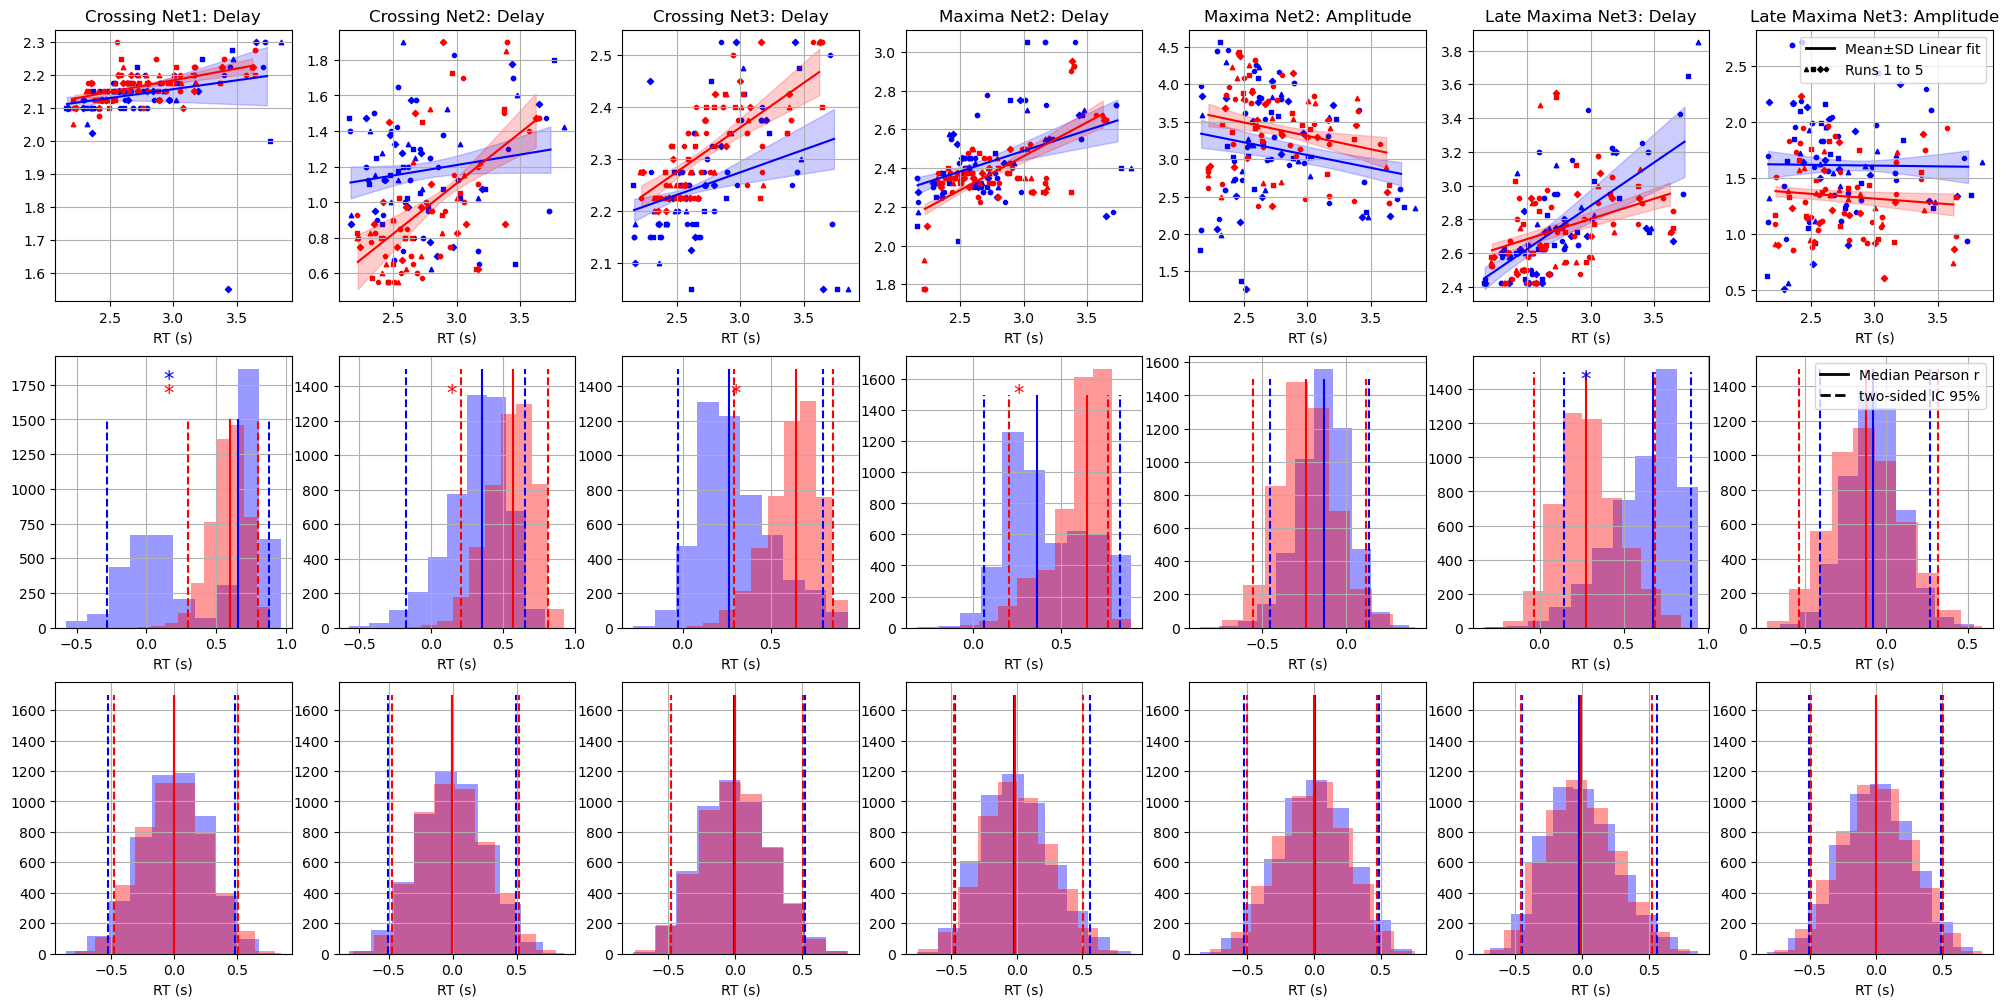

In [9]:
fig, ax=plt.subplots(3, 7, figsize=(25, 12)) #, sharey='row')

for_leg1 = []
for_leg2=[]
sub_r_to_plot =5
markers = ['o', '^', 's', 'D', 'P']

for condi in ['0', '1'] :
    iaxs=0
    for it, t_try in  enumerate(metrics_list) :
        for im, mesure in enumerate(['delay', 'ampl', 'slope', 'auc']) :
            m = correlation.query("test == @t_try and condi == @condi and type_m == @mesure")
            if m.shape[0] != 0 : 
                ax[0][iaxs].set_title(name_tp[t_try] + ': ' + name_measure[mesure])
                # linear fit curve per run
                metrics= metr[m.index, :]
                rt_runs =rt[:, int(condi), :]
                xs = []
                ys=[]
                slopes=[]
                for run in range(sub_r_to_plot) : 
                    is_na = np.where(np.isnan(metrics[run, :]))
                    if np.sum(is_na) == 0 : 
                        fit = linregress(rt_runs[run, :], metrics[run,:])
                        x = np.linspace(rt_runs[run, :].min(), rt_runs[run, :].max(), 100)
                        y=fit.slope * x + fit.intercept    
                        xs.append(x)
                        ys.append(y) 
                    ax[0][iaxs].scatter(rt_runs[run], metrics[run], s=10, c=color_event[int(condi)],  alpha = 1, marker=markers[run]) #rt_runs[:sub_r_to_plot],cmap=cmap_condi[int(condi)], alpha = 1)
                X_mean=np.stack(xs, axis=0).mean(0)
                Y_mean=np.stack(ys, axis=0).mean(0)
                Y_sd=np.stack(ys, axis=0).std(0)
                ax[0][iaxs].plot(X_mean, Y_mean, color=color_event[int(condi)], alpha = 1)
                ax[0][iaxs].fill_between(X_mean, Y_mean-Y_sd, Y_mean + Y_sd,  color=color_event[int(condi)],alpha = 0.2)
                ax[0][iaxs].set_xlabel('RT (s)')
                #ax1[iaxs].set_ylabel(name_measure[mesure])
                iaxs+=1

legend_elements = [Line2D([], [], color='k', lw=2),
  
        (Line2D([], [], color='black', marker=markers[1],linestyle='None', markersize=3),
        Line2D([], [], color='black', marker=markers[2],linestyle='None', markersize=3),
        Line2D([], [], color='black', marker=markers[3],linestyle='None', markersize=3),
        Line2D([], [], color='black', marker=markers[4],linestyle='None', markersize=3),)]

ax[0][-1].legend(
    handles=legend_elements,
    labels=['Mean±SD Linear fit', 'Runs 1 to 5'],
    handler_map={tuple: HandlerTuple(ndivide=5)},
    loc='upper right'
    )

p_perm_list = []
for condi in ['0', '1'] :
    idx_ = 0 
    for it, t_try in  enumerate(metrics_list) :
        for im, mesure in enumerate(['delay', 'ampl', 'slope', 'auc']) :
            m = correlation.query("test == @t_try and condi == @condi and type_m == @mesure")
            m_perm = correlation_perm.query("test == @t_try and condi == @condi and type_m == @mesure")
            if m.shape[0] != 0 :
                #ax[1][idx_].set_title(name_tp[t_try] + ': ' + name_measure[mesure])

                r_real = np.asarray([float(q) for q in m['corr'].values])
                real_mean = np.mean(r_real)
                real_median = np.median(r_real)
                real_ci = np.percentile(r_real, [2.5, 97.5])
                
                ax[1][idx_].hist(r_real,  color=color_event[int(condi)], alpha =0.4)
                ax[1][idx_].vlines(x=real_median, ymin=0, ymax=1500, color=color_event[int(condi)])
                ax[1][idx_].vlines(x=real_ci[0], ymin=0, ymax=1500, ls='--',  color=color_event[int(condi)])
                ax[1][idx_].vlines(x=real_ci[1], ymin=0, ymax=1500, ls='--',  color=color_event[int(condi)])
                ax[1][idx_].set_xlabel('RT (s)')

                r_perm = np.asarray([float(q) for q in m_perm['corr'].values])
                perm_mean = np.mean(r_perm)
                perm_median = np.median(r_perm)
                perm_ci = np.percentile(r_perm, [2.5, 97.5])
                ax[2][idx_].hist(r_perm,  color=color_event[int(condi)], alpha =0.4)
                ax[2][idx_].vlines(x=perm_median, ymin=0, ymax=1700, color=color_event[int(condi)])
                ax[2][idx_].vlines(x=perm_ci[0], ymin=0, ymax=1700, ls='--',  color=color_event[int(condi)])
                ax[2][idx_].vlines(x=perm_ci[1], ymin=0, ymax=1700, ls='--',  color=color_event[int(condi)])
                ax[2][idx_].set_xlabel('RT (s)')
                idx_+=1


                T_obs = np.median(r_real)
                p_perm = (np.sum(np.abs(r_perm) >= np.abs(T_obs)) + 1) / (len(r_perm) + 1)
                p_perm_list.append((real_median, condi, t_try, mesure, p_perm))

df =pd.DataFrame(p_perm_list, columns=['med', 'condi', 'test', 'type_m', 'p'])
pvals = df['p'].astype(float).values
reject, pvals_fdr, _, _ = multipletests(pvals,alpha=0.05,method='fdr_bh')
df['p_fdr'] = pvals_fdr

for condi in ['0', '1']:
    idx_ = 0
    for t_try in metrics_list:
        for mesure in ['delay', 'ampl', 'slope', 'auc']:
            row = df.query("condi == @condi and test == @t_try and type_m == @mesure")
            if row.shape[0] == 0:
                continue
            p_fdr = row['p_fdr'].iloc[0]
            if p_fdr < 0.001:
                sig = '***'
            elif p_fdr < 0.01:
                sig = '**'
            elif p_fdr < 0.05:
                sig = '*'
            else:
                sig = ''

            ax[1, idx_].text(0.5,0.95- 0.05*int(condi),f'{sig}',transform=ax[1, idx_].transAxes,ha='right',va='top',fontsize=15, color=color_event[int(condi)])
            idx_ += 1

legend_elements = [#Line2D([0], [0], color='blue', lw=2, label=f'Memorized'),
                    #Line2D([0], [0], color='red', lw=2, label=f'Novel'), 
                    Line2D([0], [0], color='k', lw=2, label=f'Median Pearson r'),
                    Line2D([0], [0], color='k',ls='--', lw=2, label=f'two-sided IC 95%')]
                    #Line2D([0], [0], color='k',marker=r'$\ast$', linestyle='None',markersize=7,label=f'p-emp signifiance level'),]
ax[1][-1].legend(handles=legend_elements, loc='upper right')#, bbox_to_anchor=(1, 1))

for a in ax.flatten():
    a.grid()
    #a.tick_params(axis='x', which='both', bottom=True, labelbottom=True)



In [8]:
metrics_list = ['desc_slop_pc2','asc_slop_pc2','area_under_pc2','area_above_pc2','0_pc1', '0_pc2', 'min_pc2', 'bump_pc3']

for condi in ['0', '1'] :
    for it, t_try in  enumerate(metrics_list) :
        for im, mesure in enumerate(['delay', 'ampl', 'slope', 'auc']) :
            m = correlation.query("test == @t_try and condi == @condi and type_m == @mesure")
            if m.shape[0] != 0 : 
                m_f_corr = m.loc[:, 'corr'].astype(float).values                
                isnan_ = np.where(np.isnan(m_f_corr))

                metrics= metr[m.index, :][isnan_, :]
                rt_runs =rt[:, int(condi), :][isnan_, :]
                trans_ = trans[isnan_, 1, int(condi), :, :]
                
                if trans_.shape[1] != 0 : 
                    print(t_try, mesure, trans_.shape)
       
    

desc_slop_pc2 slope (1, 1, 16, 197)
asc_slop_pc2 slope (1, 1, 16, 197)


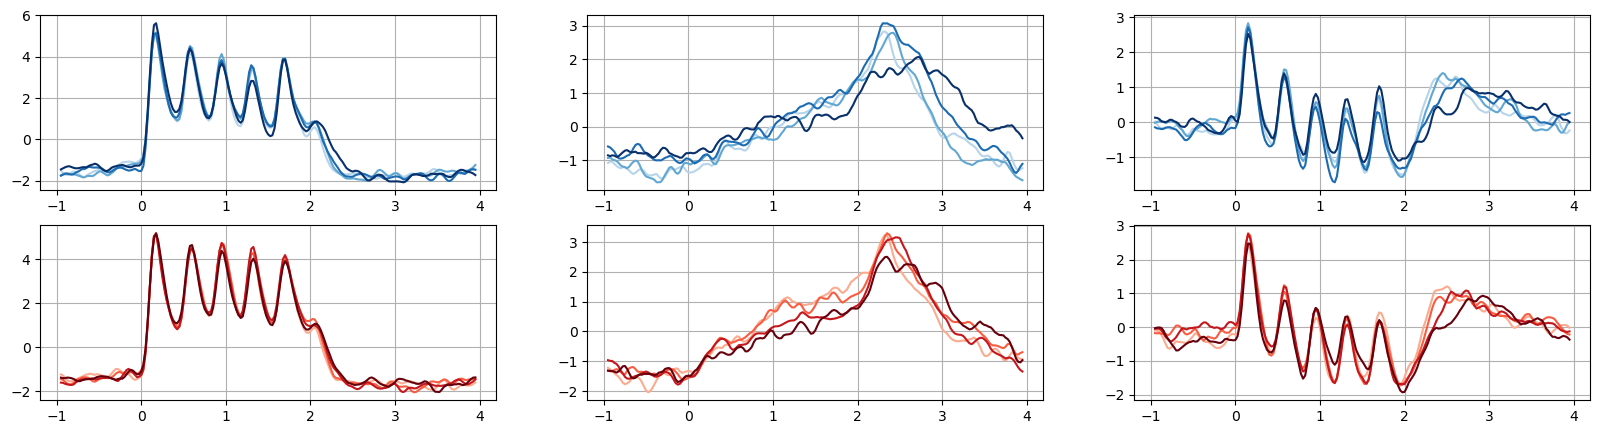

In [9]:
n_runs, n_cond, n_trials = rt.shape
_, n_pc, _, _, n_time = trans.shape

n_cat = 4
mean_transform = np.zeros((n_pc, n_cond, n_cat, n_time))

colors1 = cm.Blues(np.linspace(0.3, 1, n_cat))  
colors2 = cm.Reds(np.linspace(0.3, 1, n_cat))  
col =[colors1, colors2]
fig, ax= plt.subplots(2, 3, figsize=(20, 5))

for cond in range(n_cond):
    rt_ = rt[:, cond, :].reshape(-1)
    tr = trans[:, :, cond, :, :]
    tr = tr.transpose(0, 2, 1, 3).reshape(-1, n_pc, n_time)
    order = np.argsort(rt_)
    rt_sorted = rt_[order]
    tr_sorted = tr[order]
    bins = np.array_split(np.arange(len(rt_sorted)), n_cat)

    for cat, idx in enumerate(bins):
        mean_transform[:, cond, cat] = tr_sorted[idx].mean(axis=0)

for pc in range(3):
    for condi in range(2) :  
        for  cat in range(n_cat) :
            ax[condi, pc].plot(time_tfr, mean_transform[pc, condi, cat,:], c=col[condi][cat])
            ax[condi, pc].grid(True)


## specific time points One run

In [22]:
pca = PCA(3)
np.random.seed(0)
trans_dict ={}
rt_dict ={}
subj_list=subj_included_restricted[16]
data_grp = get_data_grp(subj_list, return_subj=False, data_path=epoch_path, polarity_cor=(False,0), type_data='tfr')[:, :, -1, :]

for pc_use in range(3):
    sorted_='RT'
    pca_transform =  pca.fit_transform(np.concat([data_grp[0, :,:], data_grp[1, :, :]], axis=-1).T)[:, pc_use]
    rt_mean_tot = {0 : [], 1: []}
    rt_mean =  {0 :[], 1: []}
    supsubj= {0 :[], 1: []}
    for ic, condi in enumerate(['1', '2'] ): 
        for subj in subj_list:
            df = df_RT[(df_RT['subject'] == subj)].reset_index(drop=True)
            df= df.dropna()
            if len(df) <4 : 
                print(subj)
            rt_condi=df[df['ev_id'] == condi].reset_index()[['RT', 'index']]

            if len(rt_condi) > nb_trials : # if the there are more than 16 trials 
                rt_condi = rt_condi.sample(n=nb_trials, random_state=None)
            else : 
                rt_condi = rt_condi.sample(n=nb_trials, replace=True)

            rt_condi_sorted = rt_condi.sort_values(by = sorted_).reset_index(drop=True)

            file = epoch_path + f'/{subj}_TFRtrials.p'
            with open(file, "rb") as f:
                TFRtr = pickle.load(f)[:, :, -1, :]
            random_index = rt_condi_sorted.loc[:, 'index'].values
            supsubj[ic].append(TFRtr[random_index,:,:])
            rt_mean[ic].append(df.loc[random_index, 'RT'])
            
    rt_mean0 = np.concat([r.values[None, :] for r in rt_mean[0]], axis=0)
    rt_mean1 = np.concat([r.values[None, :] for r in rt_mean[1]], axis=0)

    dataset0 = np.concat(supsubj[0], axis=1)
    dataset1 = np.concat(supsubj[1], axis=1)

    transform0 = np.zeros((nb_trials,  len(time_tfr)))
    transform1 = np.zeros((nb_trials,  len(time_tfr)))
        
    for tr in range(nb_trials) : 
        transform0[tr, :] = dataset0[tr, :, :].T @ pca.components_[pc_use, :]
        transform1[tr, :] = dataset1[tr, :, :].T @ pca.components_[pc_use, :]

     
    trans_dict[pc_use] = [transform0, transform1]
    rt_dict[pc_use] = [rt_mean0.mean(0), rt_mean1.mean(0)]

In [27]:
from src.behavior import get_cross_point, get_slop_pc2, area_pc2, get_slop_pc3

find_tp = {'0_pc1': lambda x, tr : get_cross_point(tr, x, tstart=90, tend=150), 
           '0_pc2': lambda x, tr :  get_cross_point(tr, x, tstart=40, tend=115), 
           '0_pc3': lambda x, tr : get_cross_point(tr, x, tstart=120, tend=140), 
           'min_pc2': lambda x, tr : np.argmax(x[tr, 100:]) + 100, 
           'bump_pc3' : lambda x, tr : 135 + np.argmax(x[tr, 135:]),
           'desc_slop_pc2': lambda x, tr : get_slop_pc2(tr, x, time=time_tfr)[0] , 
           'asc_slop_pc2' : lambda x, tr : get_slop_pc2(tr, x, time=time_tfr)[1], 
           'slop_pc3': lambda x, tr : get_slop_pc3(tr, x, time=time_tfr),
           'area_under_pc2': lambda x, tr : area_pc2(tr, x)[0], 
           'area_above_pc2': lambda x, tr : area_pc2(tr, x)[1]}

nb_trials = 16
subj_list=subj_included_restricted[nb_trials]

colors1 = cm.Blues(np.linspace(0.3, 1, nb_trials))  
colors2 = cm.Reds(np.linspace(0.3, 1, nb_trials)) 
col  =[colors1, colors2] 

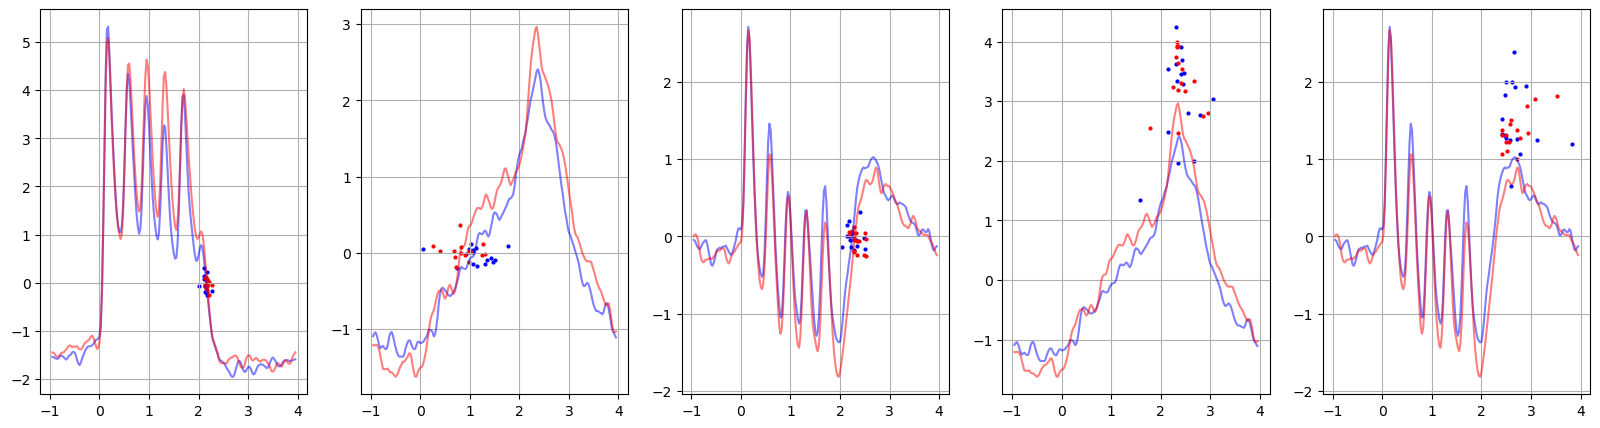

In [28]:
to_try = list(find_tp.keys())[:5]

fig, ax = plt.subplots( 1, len(to_try), figsize=(20, 5))
for t, to_t  in enumerate(to_try):
    trans = trans_dict[int(to_t[-1:])-1]
    for i in range(2):
        
        peaks = np.array([find_tp[to_t](trans[i], tr) for tr in range(trans[i].shape[0])])
       
        for tr in range(nb_trials):
            if (np.array(time_tfr)[peaks[tr]] < 2) and int(to_t[-1])==0: ax[t].plot(time_tfr, trans[i][tr])
            #if peaks[tr] == np.max(peaks):ax[t].plot(time_tfr, trans[i][tr])
            #if  trans[i][tr, peaks[tr]] >0.25 : 
            #    ax[t].plot(time_tfr, trans[i][tr])
            #    ax[t].scatter(time_tfr[peaks[tr]], trans[i][tr, peaks[tr]], s=40)

            ax[t].scatter(np.array(time_tfr)[peaks[tr]], trans[i][tr, peaks[tr]], color=color_event[i], s=4)

        ax[t].plot(time_tfr, trans[i].mean(0), color=color_event[i], alpha = 0.5)
    ax[t].grid()


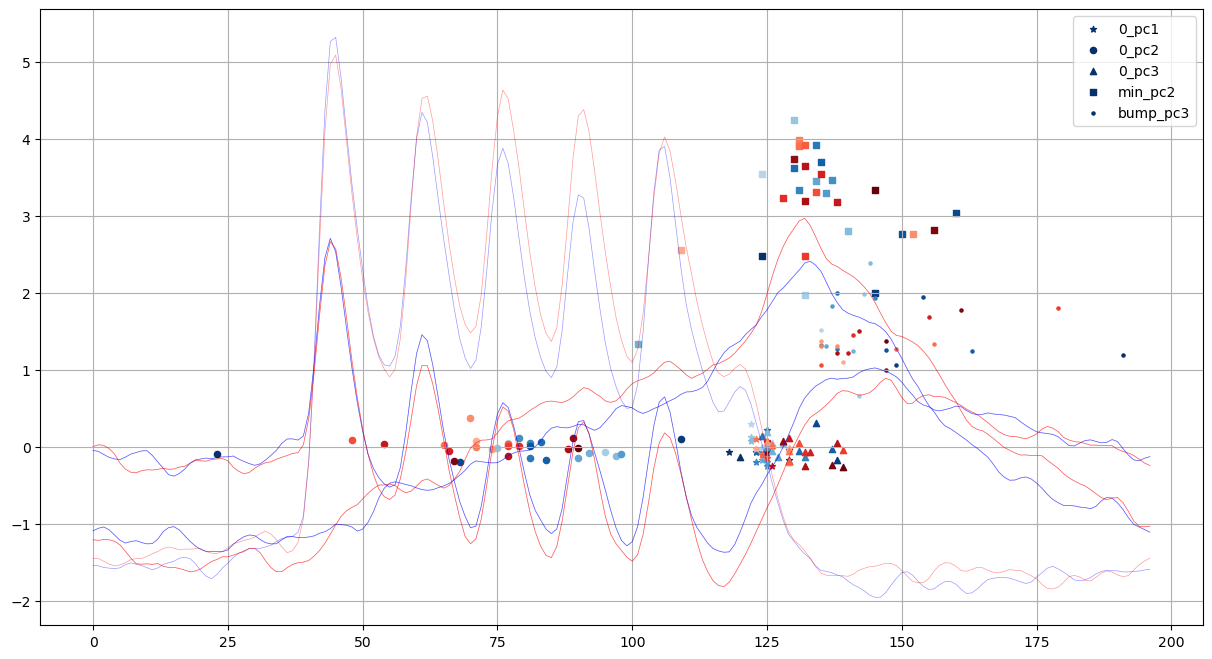

In [13]:
fig, ax=plt.subplots( figsize=(15, 8))
marker = ['*', 'o', '^', 's', '.', '+']
for t, to_t  in enumerate(to_try):
    trans = trans_dict[int(to_t[-1:])-1]
    for i in range(2):
        peaks = np.array([find_tp[to_t](trans[i], tr) for tr in range(trans[i].shape[0])])
            
        for tr in range(nb_trials) : 
            if (tr == nb_trials-1) & (i == 0) : 
                ax.scatter(np.array(peaks)[tr], trans[i][tr, int(np.array(peaks)[tr])], color=col[i][tr], s=20, marker = marker[t], label = to_t)
            else : 
                ax.scatter(np.array(peaks)[tr], trans[i][tr, int(np.array(peaks)[tr])], color=col[i][tr], s=20, marker = marker[t])

        
        ax.plot(trans[i].mean(0), color =color_event[i], linewidth = 0.5, alpha = 0.4)
ax.grid()
ax.legend()

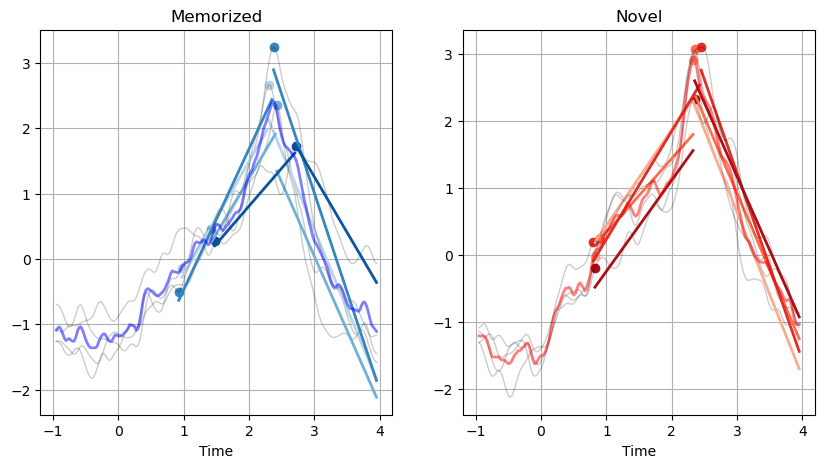

In [14]:
# plot slop PC2
trans = trans_dict[1]
rt = rt_dict[1]

fig, ax =plt.subplots(1, 2, figsize=(10, 5))

nb_cat=4
grp = int(nb_trials/nb_cat)

for j in range(2):
    the_ax = ax[j]
    for i in range(nb_cat) : 
        signal = trans[j][grp*i:grp*(1+i), :].mean(0) 
        signal = gaussian_filter1d(signal, sigma=2)
        crossing = np.array(find_tp['0_pc2'](trans[j], i))
        minima = np.argmax(signal)

        # First segment
        x1 = np.array(time_tfr[crossing:minima])
        y1 = signal[crossing:minima]
        fit1 = linregress(x1, y1)

        # Second segment
        x2 = np.array(time_tfr[minima:])
        y2 = signal[minima:]
        fit2 = linregress(x2, y2)
        the_ax.plot(time_tfr, signal, 'k', linewidth=1, alpha = 0.2)

        the_ax.plot(x1, fit1.intercept + fit1.slope * x1, lw=2, c=col[j][i*(grp)])
        the_ax.plot(x2, fit2.intercept + fit2.slope * x2, lw=2,c=col[j][i*(grp)])

        #the_ax.axvline(time_tfr[minima], color=col[j][i])
        #the_ax.axhline(signal[minima], color=col[j][i])
        the_ax.scatter(time_tfr[minima], signal[minima], color=col[j][i*(grp)])
        the_ax.scatter(time_tfr[crossing], signal[crossing], color=col[j][i*(grp)])
    the_ax.plot(time_tfr, trans[j].mean(0), color=color_event[j], alpha = 0.5, lw=2)
    the_ax.set_xlabel('Time')
    the_ax.set_title(titles[j])
    the_ax.grid(True)

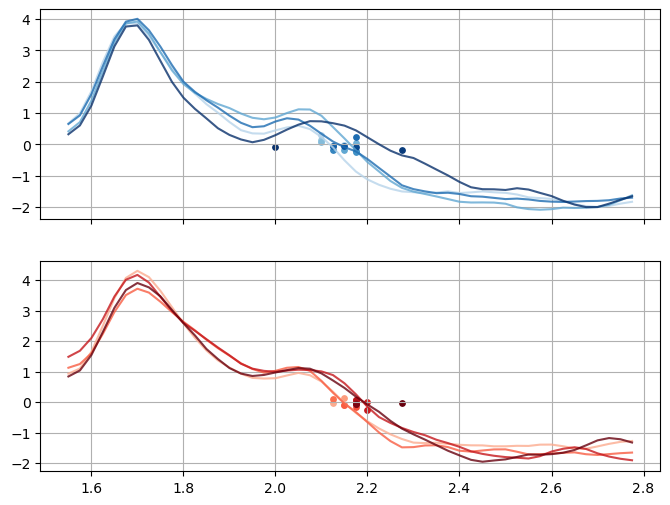

In [13]:
# plot area under the curve
trans = trans_dict[0]
rt = rt_dict[0]
fig, ax =plt.subplots(2, 1, figsize=(8, 6), sharex=True)
nb_cat = 4
grp = int(nb_trials/nb_cat)

tstart = 100
tend=150
for j in range(2):
    the_ax = ax[j]
    for tr in range(nb_trials):
        peaks1 = find_tp['0_pc1'](trans[j], tr)        
        the_ax.scatter(np.array(time_tfr)[peaks1], trans[j][tr][peaks1], color=col[j][tr], s=15)

    for i in range(nb_cat) : 
        signal = trans[j][grp*i:grp*(1+i), :].mean(0) 
        maxima = np.argmax(signal[tstart:tend]) + tstart

        x = np.array(time_tfr[tstart:tend])
        the_ax.plot(x, signal[tstart:tend], color=col[j][i*(grp+1)], alpha=0.8)
        #the_ax.fill_between(x,signal[tstart:tend],0,where=signal[tstart:tend] > 0,color=col[j][i*(grp+1)],alpha=0.3)
for a in ax.flatten() :
    a.grid()

    

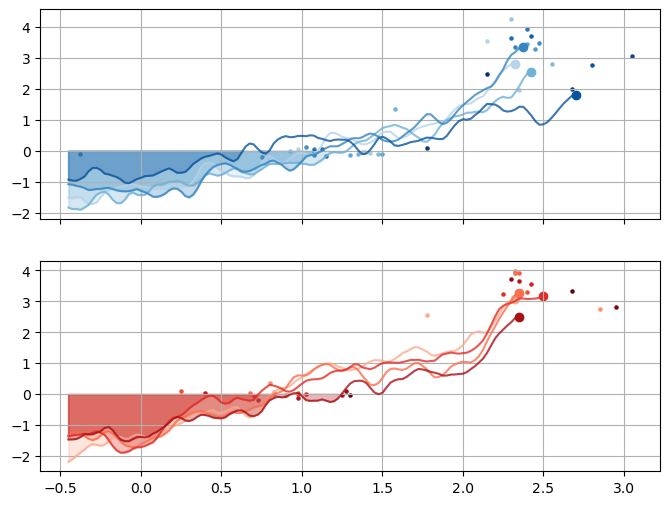

In [15]:
# plot area under the curve bis
trans = trans_dict[1]
rt = rt_dict[1]
fig, ax =plt.subplots(2, 1, figsize=(8, 6), sharex=True)
nb_cat = 4
grp = int(nb_trials/nb_cat)

for j in range(2):
    the_ax = ax[j]
    for tr in range(nb_trials):
        peaks1 = find_tp['0_pc2'](trans[j], tr)
        peaks2 = find_tp['min_pc2'](trans[j], tr)
        
        the_ax.scatter(np.array(time_tfr)[peaks1], trans[j][tr][peaks1], color=col[j][tr], s=5)
        the_ax.scatter(np.array(time_tfr)[peaks2], trans[j][tr][peaks2], color=col[j][tr], s=5)

    for i in range(nb_cat) : 
        signal = trans[j][grp*i:grp*(1+i), :].mean(0) 
        minima = np.argmax(signal[100:]) +100
        the_ax.scatter(time_tfr[minima], signal[minima], color=col[j][i*(grp)])
        
        x = np.array(time_tfr[20:minima])
        the_ax.plot(x, signal[20:minima], color=col[j][i*(grp)], alpha=0.8)
        the_ax.fill_between(
            x,
            signal[20:minima],
            0,
            where=signal[20:minima] < 0,
            color=col[j][i*(grp)],
            alpha=0.3
        )
    
        #the_ax.plot(x, signal[20:minima], color=col[j][i*(grp+1)], alpha=0.8)
        #the_ax.fill_between(
        #    x,
        #    signal[20:minima],
        #    0,
        #    where=signal[20:minima] > 0,
        #    color=col[j][i*(grp+1)],
        #    alpha=0.3
        #)
for a in ax.flatten() :
    a.grid()

    

/tmp/ipykernel_30121/1006454653.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


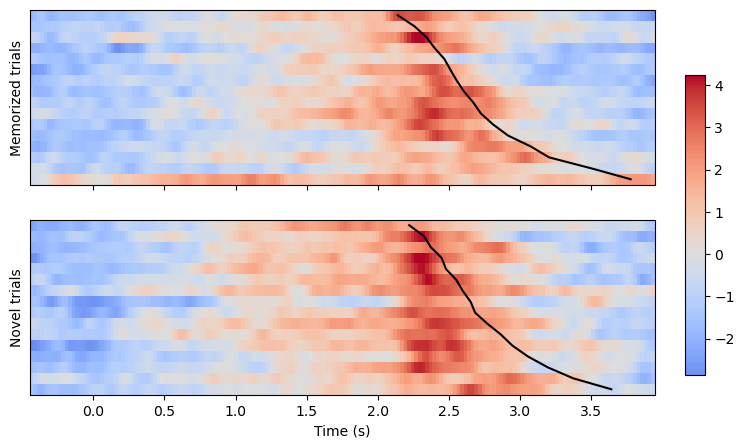

In [16]:
fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True, gridspec_kw={'right': 0.75})

condi = ['Memorized', 'Novel']
pc =1
# Heatmaps without individual colorbars
hm0 = sns.heatmap(trans_dict[pc][0][:, 20:],cmap='coolwarm',center=0,ax=ax[0],yticklabels=False,cbar=False)
hm1 = sns.heatmap(trans_dict[pc][1][:, 20:], cmap='coolwarm',center=0,ax=ax[1], yticklabels=False,cbar=False)
cax = fig.add_axes([0.78, 0.15, 0.02, 0.6])  # [left, bottom, width, height]
cbar = fig.colorbar(
    hm0.collections[0],
    cax=cax,
    orientation='vertical'
)
#cbar.set_label('Network activity') 

for i, (a, rt) in enumerate(zip(ax, [rt_dict[pc][0], rt_dict[pc][1]])):

    # Hide heatmap x-axis
    a.set_xticks([])
    a.set_xticklabels([])

    ax_rt = a.twiny()
    ax_rt.xaxis.set_ticks_position('bottom')
    ax_rt.xaxis.set_label_position('bottom')
    ax_rt.spines['bottom'].set_position(('outward', 0))  

    y = np.arange(trans_dict[pc][i].shape[0]) + 0.5
    ax_rt.plot(rt, y, color='k', lw=1.5)

    ax_rt.set_ylim(a.get_ylim())
    ax_rt.set_xlim(time_tfr[20], time_tfr[-1])

    if i == 1:
        ax_rt.set_xlabel('Time (s)')
    else:
        ax_rt.set_xticklabels([])

    a.set_ylabel(f'{condi[i]} trials')

plt.tight_layout()


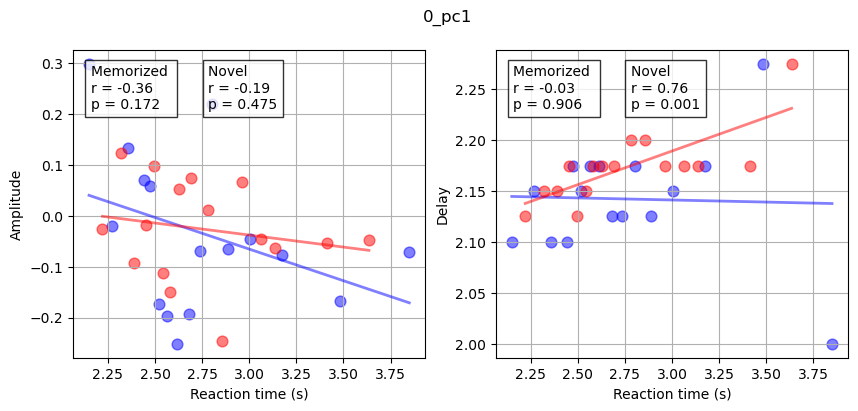

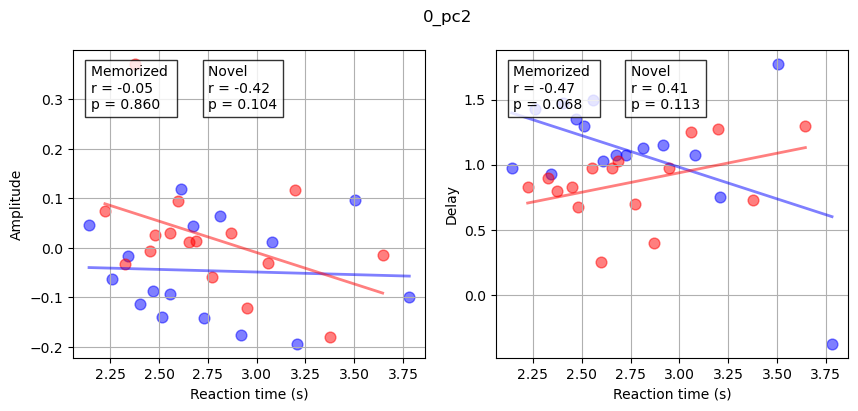

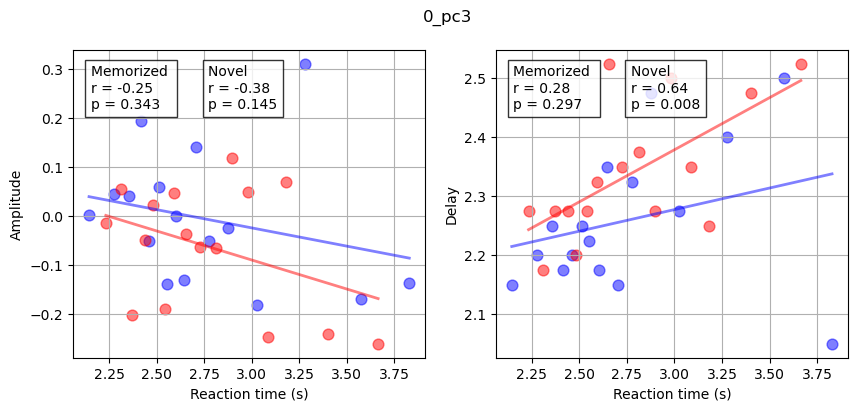

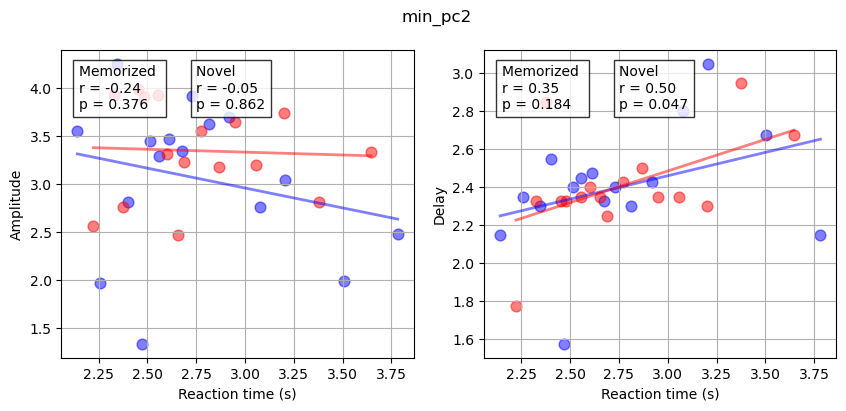

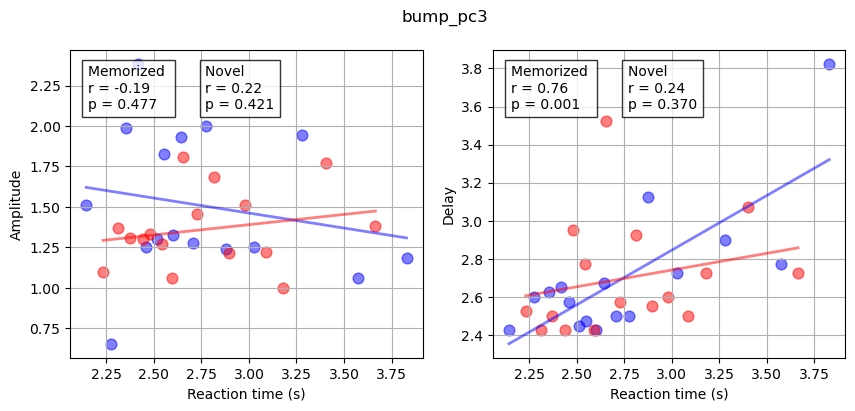

In [17]:
for to_t in to_try :
    
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(to_t)
    trans = trans_dict[int(to_t[-1:])-1]
    rt = rt_dict[int(to_t[-1:])-1]
    titles = ["Memorized", "Novel"]

    for i in range(2):

        if to_t == '0_pc1' : 
            peaks = np.array([find_tp['0_pc1'](trans[i], tr) for tr in range(trans[i].shape[0])])
        elif to_t == '0_pc2' : 
            peaks = np.array([find_tp['0_pc2'](trans[i], tr) for tr in range(trans[i].shape[0])])
        else : 
            peaks = np.array([find_tp[to_t](trans[i], tr) for tr in range(trans[i].shape[0])])

        ampl = trans[i][np.arange(trans[i].shape[0]), peaks]
        delay = np.asarray(time_tfr)[peaks]

        r_amp, p_amp = pearsonr(rt[i], ampl)
        r_del, p_del = pearsonr(rt[i], delay)

        ax[0].scatter(rt[i], ampl, s=60, color=color_event[i], alpha = 0.5)
        fit = linregress(rt[i], ampl)
        x = np.linspace(rt[i].min(), rt[i].max(), 100)
        ax[0].plot(x, fit.slope * x + fit.intercept,color=color_event[i], lw=2, alpha = 0.5)
        ax[0].text(0.05+i/3, 0.95,f"{titles[i]} \nr = {r_amp:.2f}\np = {p_amp:.3f}",transform=ax[0].transAxes,va="top", bbox=dict(facecolor="white", alpha=.8))

        ax[1].scatter(rt[i], delay, s=60, color=color_event[i], alpha = 0.5)
        fit = linregress(rt[i], delay)
        x = np.linspace(rt[i].min(), rt[i].max(), 100)
        ax[1].plot(x, fit.slope * x + fit.intercept,color=color_event[i], lw=2, alpha = 0.5)
        ax[1].text(1.25+i/3, 0.95,f"{titles[i]} \nr = {r_del:.2f}\np = {p_del:.3f}",transform=ax[0].transAxes,va="top", bbox=dict(facecolor="white", alpha=.8))


    ax[0].set_xlabel("Reaction time (s)")
    ax[1].set_xlabel("Reaction time (s)")
    ax[0].set_ylabel("Amplitude")
    ax[1].set_ylabel("Delay")
    ax[0].grid()
    ax[1].grid()


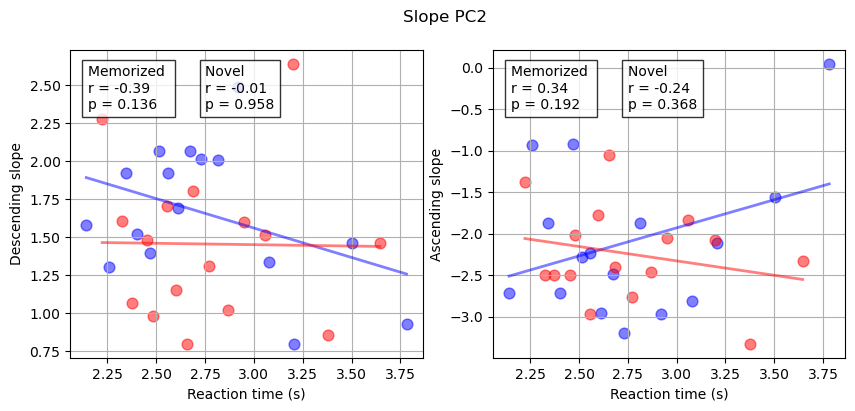

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Slope PC2')
trans = trans_dict[1]
rt = rt_dict[1]

titles = ["Memorized", "Novel"]

for i in range(2):
    slope1 = np.array([find_tp['desc_slop_pc2'](trans[i], tr) for tr in range(trans[i].shape[0])])
    slope2 = np.array([find_tp['asc_slop_pc2'](trans[i], tr) for tr in range(trans[i].shape[0])])

    r_amp, p_amp = pearsonr(rt[i], slope1)
    r_del, p_del = pearsonr(rt[i], slope2)

    ax[0].scatter(rt[i], slope1, s=60, color=color_event[i], alpha = 0.5)
    fit = linregress(rt[i], slope1)
    x = np.linspace(rt[i].min(), rt[i].max(), 100)
    ax[0].plot(x, fit.slope * x + fit.intercept,color=color_event[i], lw=2, alpha = 0.5)
    ax[0].text(0.05+i/3, 0.95,f"{titles[i]} \nr = {r_amp:.2f}\np = {p_amp:.3f}",transform=ax[0].transAxes,va="top", bbox=dict(facecolor="white", alpha=.8))

    ax[1].scatter(rt[i], slope2, s=60, color=color_event[i], alpha = 0.5)
    fit = linregress(rt[i], slope2)
    x = np.linspace(rt[i].min(), rt[i].max(), 100)
    ax[1].plot(x, fit.slope * x + fit.intercept,color=color_event[i], lw=2, alpha = 0.5)
    ax[1].text(1.25+i/3, 0.95,f"{titles[i]} \nr = {r_del:.2f}\np = {p_del:.3f}",transform=ax[0].transAxes,va="top", bbox=dict(facecolor="white", alpha=.8))


ax[0].set_xlabel("Reaction time (s)")
ax[1].set_xlabel("Reaction time (s)")
ax[0].set_ylabel("Descending slope")
ax[1].set_ylabel("Ascending slope")
ax[0].grid()
ax[1].grid()


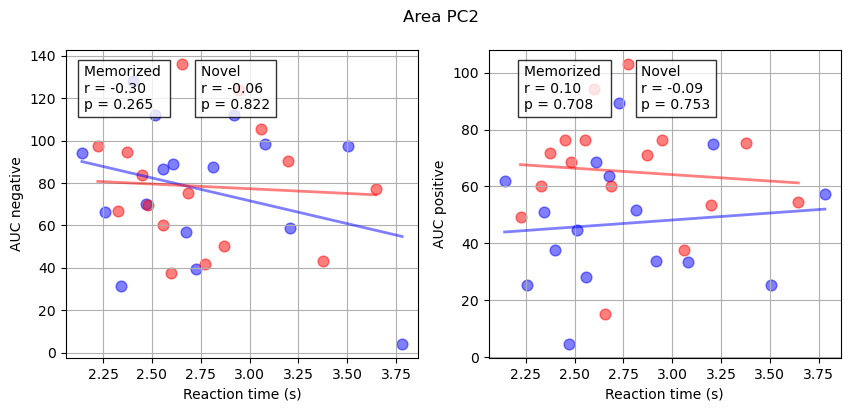

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Area PC2')
trans = trans_dict[1]
rt = rt_dict[1]

for i in range(2):
    slope1 = np.array([find_tp['area_under_pc2'](trans[i], tr) for tr in range(trans[i].shape[0])])
    slope2 = np.array([find_tp['area_above_pc2'](trans[i], tr) for tr in range(trans[i].shape[0])])

    r_amp, p_amp = pearsonr(rt[i], slope1)
    r_del, p_del = pearsonr(rt[i], slope2)

    ax[0].scatter(rt[i], slope1, s=60, color=color_event[i], alpha = 0.5)
    fit = linregress(rt[i], slope1)
    x = np.linspace(rt[i].min(), rt[i].max(), 100)
    ax[0].plot(x, fit.slope * x + fit.intercept,color=color_event[i], lw=2, alpha = 0.5)
    ax[0].text(0.05+(i/3), 0.95,f"{titles[i]} \nr = {r_amp:.2f}\np = {p_amp:.3f}",transform=ax[0].transAxes,va="top", bbox=dict(facecolor="white", alpha=.8))

    ax[1].scatter(rt[i], slope2, s=60, color=color_event[i], alpha = 0.5)
    fit = linregress(rt[i], slope2)
    x = np.linspace(rt[i].min(), rt[i].max(), 100)
    ax[1].plot(x, fit.slope * x + fit.intercept,color=color_event[i], lw=2, alpha = 0.5)
    ax[1].text(1.3+(i/3), 0.95,f"{titles[i]} \nr = {r_del:.2f}\np = {p_del:.3f}",transform=ax[0].transAxes,va="top", bbox=dict(facecolor="white", alpha=.8))


ax[0].set_xlabel("Reaction time (s)")
ax[1].set_xlabel("Reaction time (s)")
ax[0].set_ylabel("AUC negative")
ax[1].set_ylabel("AUC positive")
ax[0].grid()
ax[1].grid()


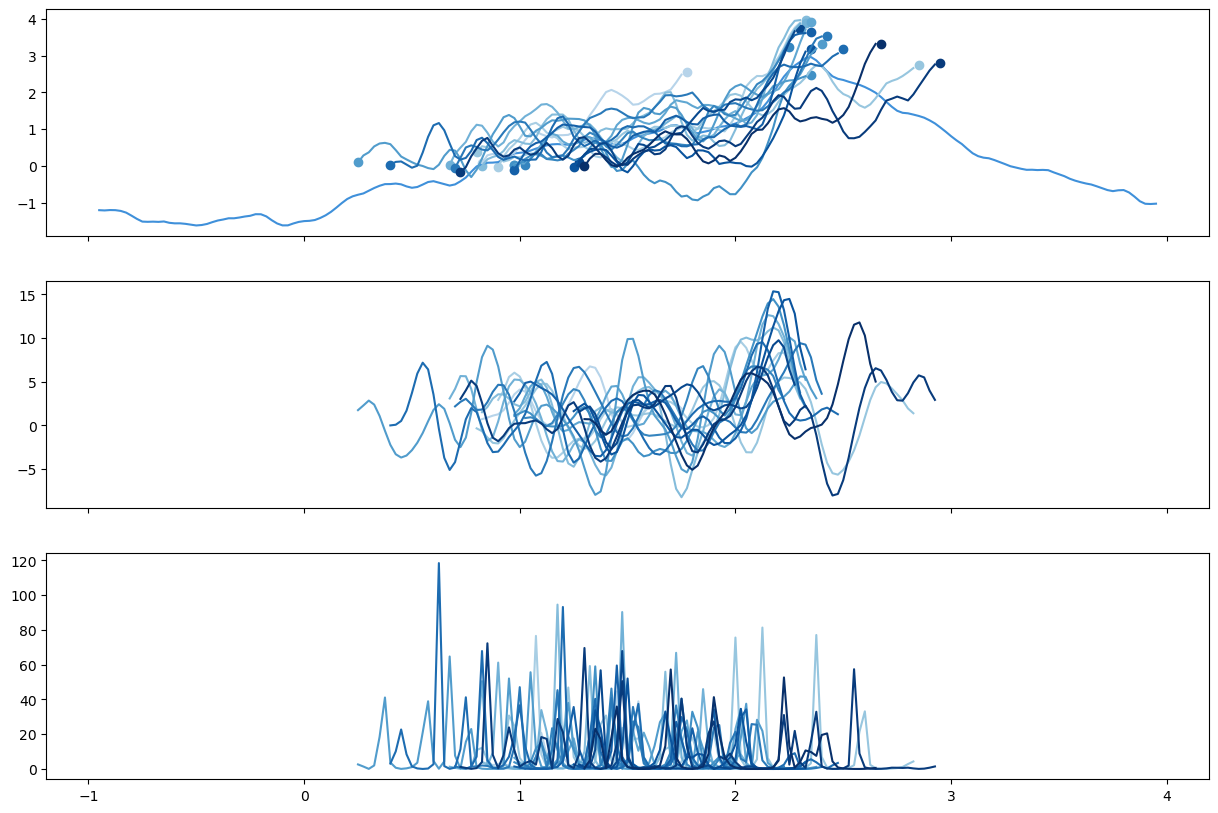

In [20]:
# curvature 

fig, ax=plt.subplots(3, 1, sharex=True, figsize=(15, 10))
trans = trans_dict[1][1]
crossings = np.array([find_tp['0_pc2'](trans, tr) for tr in range(trans.shape[0])])
minima = np.array([find_tp['min_pc2'](trans, tr) for tr in range(trans.shape[0])])
ax[0].plot(time_tfr, trans.mean(0))

for i in range(trans.shape[0]): 
    if i%1 == 0 :
        signal = trans[i,crossings[i]:minima[i] ]
        dt=np.array(time_tfr[crossings[i]:minima[i]])
        
        ax[0].plot(time_tfr[crossings[i]:minima[i]], signal, color=col[0][i])
        ax[0].scatter(time_tfr[crossings[i]], trans[i, crossings[i]],  color=col[0][i])
        ax[0].scatter(time_tfr[minima[i]], trans[i, minima[i]],  color=col[0][i])
        signal = gaussian_filter1d(signal, sigma=2)
        dy = np.gradient(signal, dt)
        d2y = np.gradient(dy, dt)

        curvature = np.abs(d2y) / (1 + dy**2)**1.5
        ax[1].plot(time_tfr[crossings[i]:minima[i]], dy,  color=col[0][i])
        ax[2].plot(time_tfr[crossings[i]:minima[i]], curvature,  color=col[0][i])


    

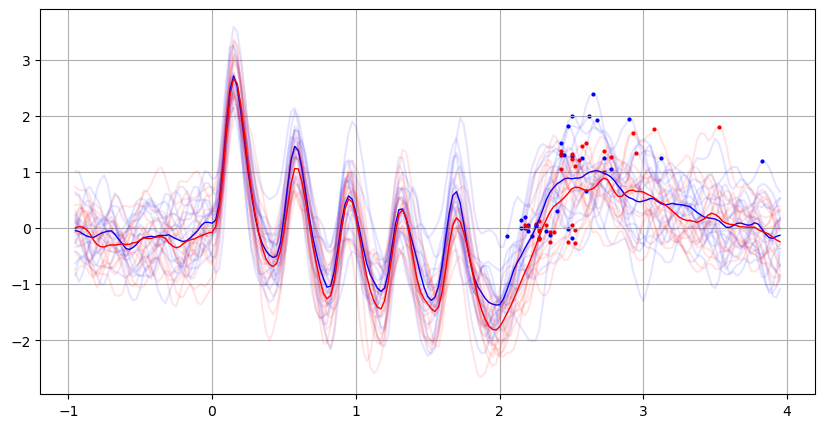

In [21]:
## Good figure
fig, ax=plt.subplots(figsize=(10, 5))
trans = trans_dict[2]
for i in range(2) :
    ax.plot(time_tfr, trans[i].mean(0), c=color_event[i], linewidth= 1)

    #peaks = np.array([find_tp['0_pc2'](trans[i][:, :150], tr) for tr in range(trans[i].shape[0])])
    for spe_tp in ['bump_pc3', '0_pc3'] : 
        peaks = np.array([find_tp[spe_tp](trans[i], tr) for tr in range(trans[i].shape[0])])

        for tr in range(nb_trials):
            ax.plot(time_tfr, trans[i][tr],  color=color_event[i], alpha = 0.05)
            ax.scatter(time_tfr[peaks[tr]], trans[i][tr, peaks[tr]],s=4, color=color_event[i]) 

ax.grid()

## Nice plot

/tmp/ipykernel_4458/3502082502.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


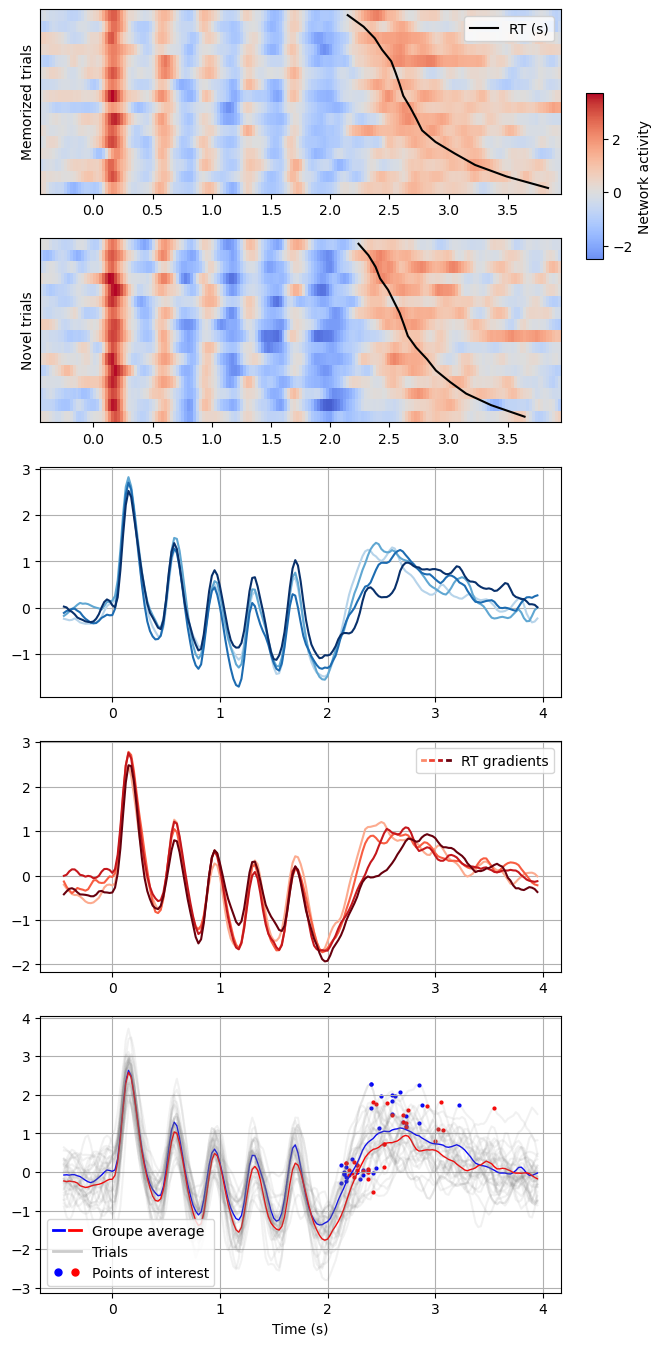

In [10]:
fig, ax = plt.subplots(5, 1, figsize=(10/1.2, 20/1.2), sharex=False, gridspec_kw={'right': 0.75}, height_ratios=[8/60, 8/60, 10/60, 10/60, 12/60])
#fig.suptitle('Network 1', y=0.9)
pc =2
dataset_label = '_mf70-160'
pc_use= pc
r=500
n_cat = 4
colors1 = cm.Blues(np.linspace(0.3, 1, n_cat))  
colors2 = cm.Reds(np.linspace(0.3, 1, n_cat))  
col = [colors1, colors2]
file = OUT_PATH + f'/Behavior{dataset_label}/tp_rt_{r}.pkl'
with open(file, "rb") as f:
    rt = pickle.load(f)
file = OUT_PATH + f'/Behavior{dataset_label}/tp_trans_{r}.pkl'
with open(file, "rb") as f:
    trans = pickle.load(f)
# Heatmaps without individual colorbars
hm0 = sns.heatmap(trans[0, pc, 0, :, 20:],cmap='coolwarm',center=0,ax=ax[0],yticklabels=False,cbar=False)
hm1 = sns.heatmap(trans[0, pc, 1, :, 20:], cmap='coolwarm',center=0,ax=ax[1], yticklabels=False,cbar=False)
cax = fig.add_axes([0.78, 0.73, 0.02, 0.1])  # [left, bottom, width, height]
cbar = fig.colorbar(hm0.collections[0],cax=cax,orientation='vertical')
cbar.set_label('Network activity')

for i, (a, rt) in enumerate(zip(ax[:2], [rt[0, 0, :], rt[0, 1, :]])):

    # Hide heatmap x-axis
    a.set_xticks([])
    a.set_xticklabels([])

    ax_rt = a.twiny()
    ax_rt.xaxis.set_ticks_position('bottom')
    ax_rt.xaxis.set_label_position('bottom')
    ax_rt.spines['bottom'].set_position(('outward', 0))  

    y = np.arange(nb_trials) + 0.5
    ax_rt.plot(rt, y, color='k', lw=1.5, label ='RT (s)')
    ax_rt.set_xlim(time_tfr[20], time_tfr[-1])

    a.set_ylabel(f'{titles[i]} trials')
    if i == 0 : ax_rt.legend()

# grp
file = path + f'tp_rt_{r}.pkl'
with open(file, "rb") as f:
    rt = pickle.load(f)

file = path + f'tp_trans_{r}.pkl'
with open(file, "rb") as f:
    trans = pickle.load(f)

n_runs, n_cond, n_trials = rt.shape
_, n_pc, _, _, n_time = trans.shape

n_cat = 4
grp = int(nb_trials/n_cat)
mean_transform = np.zeros((n_pc, n_cond, n_cat, n_time))

for cond in range(n_cond):
    rt_ = rt[:, cond, :].reshape(-1)
    tr = trans[:, :, cond, :, :]
    tr = tr.transpose(0, 2, 1, 3).reshape(-1, n_pc, n_time)
    order = np.argsort(rt_)
    rt_sorted = rt_[order]
    tr_sorted = tr[order]
    bins = np.array_split(np.arange(len(rt_sorted)), n_cat)

    for cat, idx in enumerate(bins):
        mean_transform[:, cond, cat] = tr_sorted[idx].mean(axis=0)

for condi in range(2) :  
    for  cat in range(n_cat) :
        ax[2+condi].plot(time_tfr[20:], mean_transform[pc, condi, cat,20:], c=col[condi][cat])
        ax[2+condi].grid(True)


from matplotlib.legend_handler import HandlerTuple
blues = plt.cm.Blues([0.4, 0.6, 0.8, 1.0])
gradient_lines = tuple(Line2D([0], [0], color=c, lw=2) for c in blues)
ax[3].legend([gradient_lines],["RT gradients"],handler_map={tuple: HandlerTuple(ndivide=None)}, loc='upper right')

reds = plt.cm.Reds([0.4, 0.6, 0.8, 1.0])
gradient_lines = tuple(Line2D([0], [0], color=c, lw=2) for c in reds)
ax[3].legend([gradient_lines],["RT gradients"],handler_map={tuple: HandlerTuple(ndivide=None)}, loc='upper right')

# correlation over 500 runs

for i in range(2) :
    ax[4].plot(time_tfr[20:], trans[0, pc, i, :, 20:].mean(0), c=color_event[i], linewidth= 1, label =titles[i])
    
    if pc == 2:
        list_tp = ['bump_pc3', '0_pc3'] 
    elif pc==1 : 
        list_tp = ['min_pc2', '0_pc2']
    elif pc==0 : 
        list_tp = ['0_pc1']

    for spe_tp in list_tp : 
        peaks = np.array([find_tp[spe_tp](trans[0, pc, i, :, :][:, :], tr) for tr in range(nb_trials)])

        for tr in range(nb_trials):
            ax[4].plot(time_tfr[20:], trans[0, pc, i, tr, 20:],  color='grey', alpha = 0.05)
            ax[4].scatter(time_tfr[peaks[tr]], trans[0, pc, i, tr, peaks[tr]],s=4, color=color_event[i]) 

            if tr == 0 :
                ax[4].plot(time_tfr[20:], trans[0, pc, i, tr, 20:],  color='grey', alpha = 0.05, label = 'Trials')
                ax[4].scatter(time_tfr[peaks[tr]], trans[0, pc, i, tr, peaks[tr]],s=4, color=color_event[i], label='points of interest') 

handles = (
    Line2D([0], [0], color=color_event[0], lw=2),
    Line2D([0], [0], color=color_event[1], lw=2),
)

trial_handle = Line2D([0], [0], color='grey', alpha=0.4, lw=2)
poi_handles = (
    Line2D([0], [0], marker='o', linestyle='', color=color_event[0], markersize=5),
    Line2D([0], [0], marker='o', linestyle='', color=color_event[1], markersize=5),
)

ax[4].legend(
    [handles, trial_handle, poi_handles],
    ['Groupe average', 'Trials', 'Points of interest'],
    handler_map={tuple: HandlerTuple(ndivide=None)}, 
    loc='lower left'
)
ax[4].set_xlabel('Time (s)')
ax[4].grid()
plt.tight_layout()

## Get the compo 2 and see if we need them all 

In [ ]:

PC2 = pd.read_csv(OUT_PATH + '/grpPCA/supsubj_concat/grp_concat_Compo_PCA5.csv').query('freq == "high_gamma"').drop(columns = ['Unnamed: 0', 'compo', 'freq'])
PC2_thr = CompoThr(PC2.values.T)

subj_included = [file.replace('_epochs.p', '') for file in os.listdir(epoch_path) if file[-len('epochs.p'):] == 'epochs.p']
subj_included = ExcludSubj(subj_included=subj_included, data_path=epoch_path)
coord, areas, elect_list, subj_list, region = GetInfo(subj_included, data_path=epoch_path)



In [ ]:
idx_important = np.where(PC2_thr[:, 1] > 0)[0]
subj_important = np.unique(np.array(subj_list)[idx_important])

## Back projection

In [ ]:
pc_use=1
PCs = pd.read_csv(OUT_PATH + '/grpPCA/supsubj_concat/grp_concat_Compo_PCA5.csv').query('freq == "high_gamma"').drop(columns = ['Unnamed: 0', 'compo', 'freq']).values
PCs_thr = CompoThr(PCs.T).T

TSs = pd.read_csv(OUT_PATH + '/grpPCA/supsubj_concat/grp_concat_Xtrans_PCA5.csv').query('freq == "high_gamma"').drop(columns = ['Unnamed: 0', 'compo', 'freq', 'subj', 'expl_var']).values

act = TSs[pc_use, None, :].T.dot(PCs[pc_use,None, :])

# this is the time course of PC2 channles space
act = np.concat([act[None, :int(395/2), :], act[None,int(395/2):, :]], axis=0)

#
coord, areas, elect_list, subj_list, region = GetInfo(subj_included=subj_included, data_path=epoch_path)


In [ ]:
TFR_tr=[]
act=[]
RT_1=[]
RT_2=[]

for subj in subj_included_restricted[16]:
    file = epoch_path + f'/{subj}_TFRtrials.p'
    with open(file, "rb") as f:
        TFRtr = pickle.load(f)[:, :, -1, :]

    df = df_RT[(df_RT['subject'] == subj)].reset_index()

    id_ev1 = df[df['ev_id'] == '1'].index.values
    id_ev1 = random.sample(list(id_ev1), nb_trials)
    id_ev2 = df[df['ev_id'] == '2'].index.values
    id_ev2 = random.sample(list(id_ev2), nb_trials)
    
    RT_1.append(df.loc[id_ev1, 'RT'].values)
    RT_2.append(df.loc[id_ev2, 'RT'].values)

    TFR_trials_filled = np.full((nb_trials, 2, TFRtr.shape[1], TFRtr.shape[2]), np.nan)
    TFR_trials_filled[:len(id_ev1), 0, :] =  TFRtr[id_ev1, :, :] 
    TFR_trials_filled[:len(id_ev2), 1, :] =  TFRtr[id_ev2, :, :]

    # Get the activiation
    ch_index = np.where(np.array(subj_list) == subj)[0]

    TFR_tr_transf= np.zeros((16, 2, 197))
    TFR_tr_act = np.zeros((16, 2,len(ch_index),197) )
    for tr in range(16) :
        for condi in range(2):
            TFR_tr_transf[tr, condi, :] = TFR_trials_filled[tr, condi, :,:].T @ PCs[pc_use, ch_index]
            TFR_tr_act[tr, condi, :,: ] =  PCs[None,pc_use, ch_index, None] * TFR_trials_filled[tr, condi, :, :]   
    
    TFR_tr.append(TFR_tr_transf)
    act.append(TFR_tr_act)   

RT = np.concat([np.vstack(RT_1)[None, :], np.vstack(RT_2)[None, :]], axis=0)
neural = np.concat([t[None, :,:] for t in TFR_tr], axis=0)


In [ ]:
neural = np.transpose(neural, (2, 0, 1, 3)) # condi, subject, trials, time RT.shape # condi, subj, tirals

(2, 24, 16, 197)

In [ ]:
cor=[]
for si in range(24):
    corr = np.zeros((2, act[si].shape[2], 197))
    pval = np.zeros_like(corr)

    for condi in range(2):
        rt = RT[condi, si]         
        for ch in range(act[si].shape[2]):
            for t in range(197):
                x = act[si][:, condi, ch, t]
                corr[condi, ch, t], pval[condi, ch, t] = spearmanr(x, rt) #pearsonr(x, rt)
    
    cor.append(corr)
cor = np.concat(cor, axis=1)
        

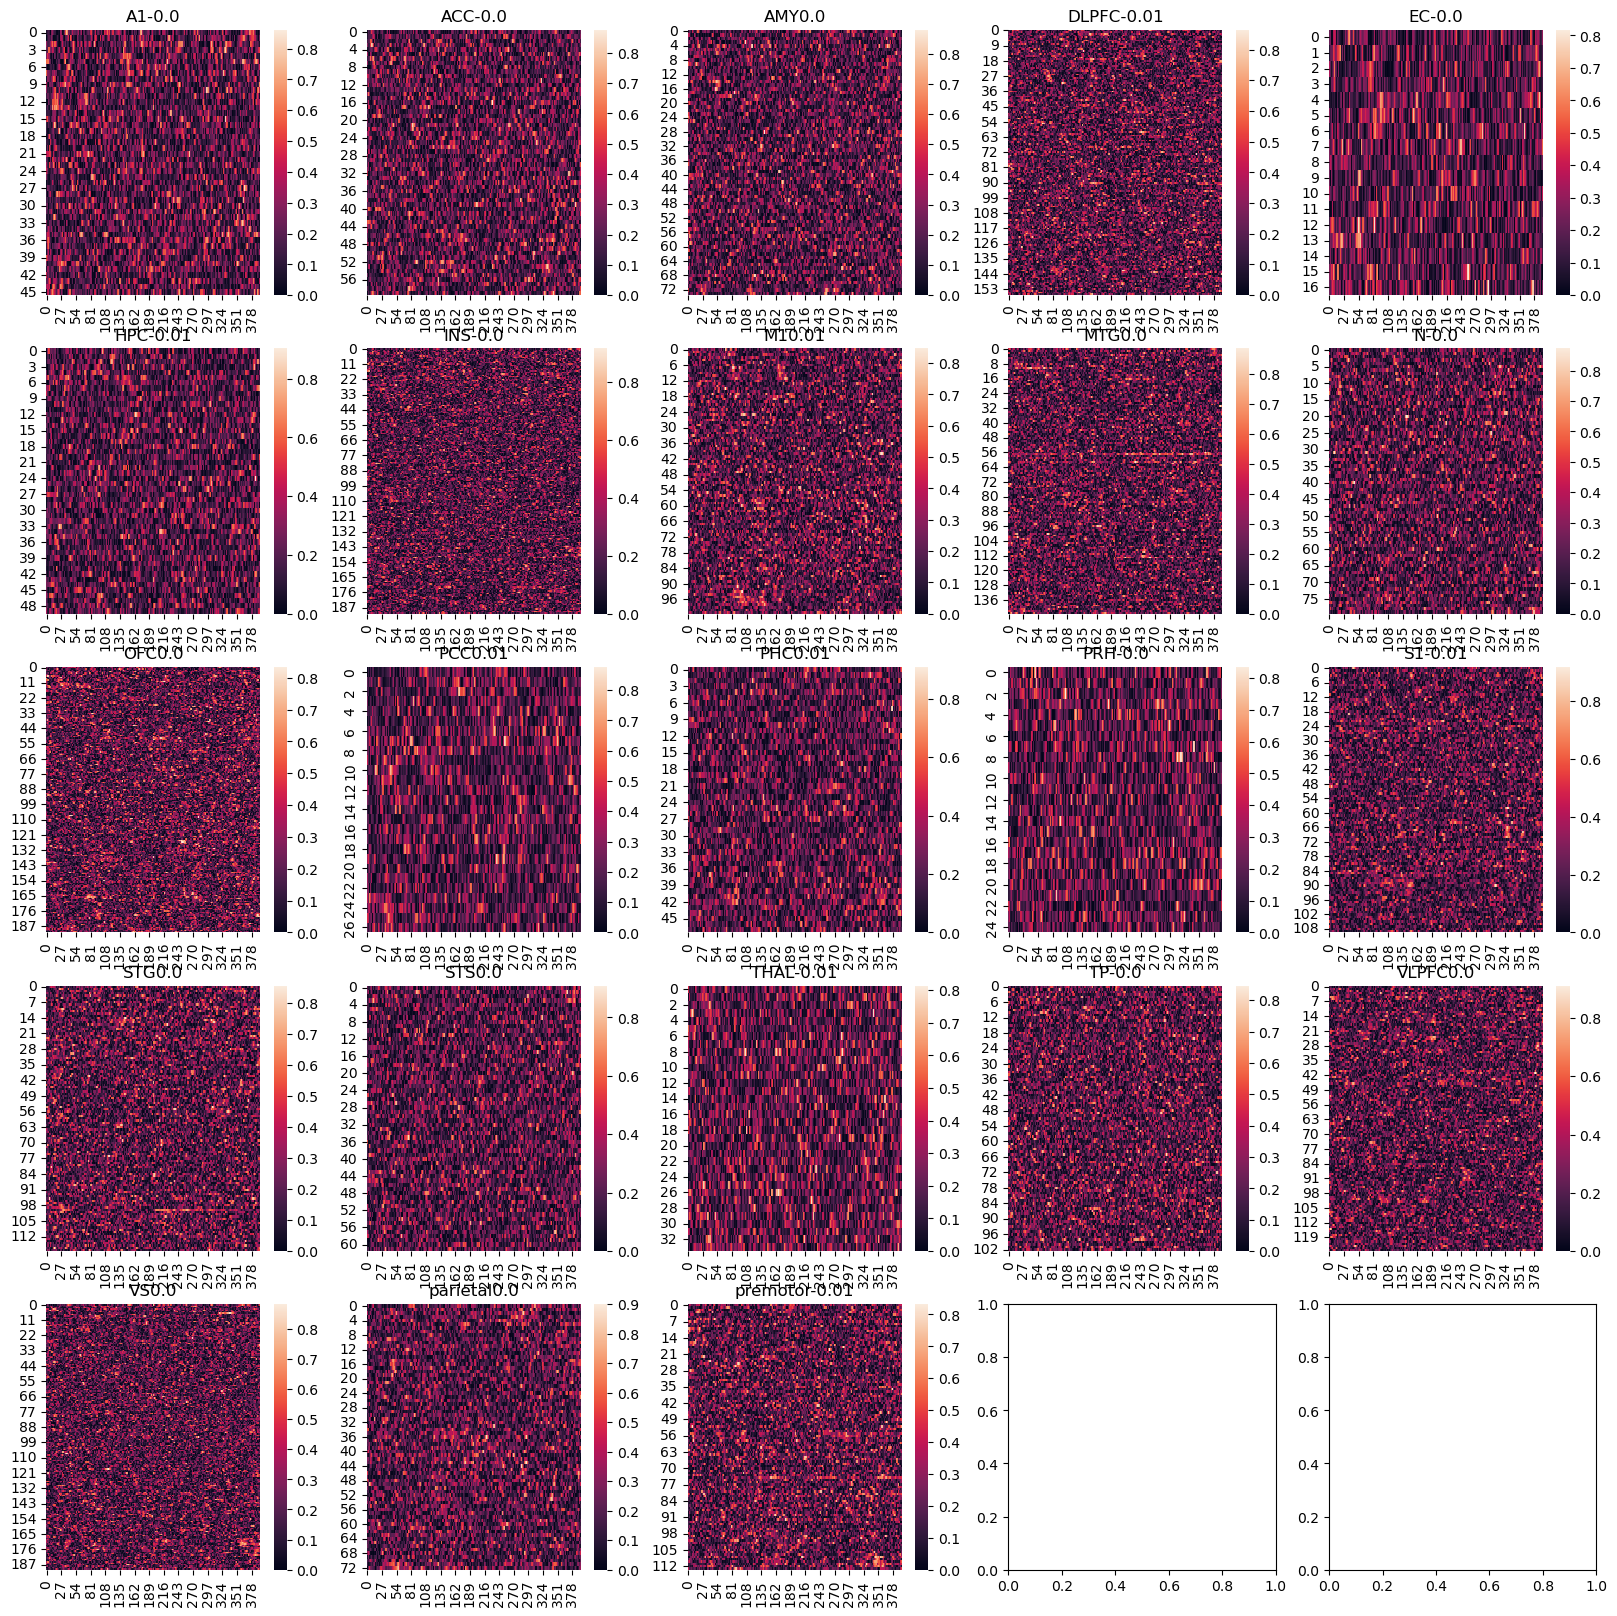

In [ ]:
coord, areas, elect_list, subj_list, regions = GetInfo(subj_included_restricted[16], data_path=epoch_path)

fig, ax= plt.subplots(5, 5, figsize=(20, 20))

for a, r in zip(ax.flatten(), np.unique(regions)): 
    id_r = np.where(np.array(regions) ==r)[0]
    corr_regions = np.concat([cor[0, id_r, :], cor[1, id_r, :]], axis=-1)
    sns.heatmap(abs(corr_regions), ax=a)
    a.set_title(r + str(np.round(np.mean(corr_regions), 2)))


In [ ]:
rows = []
for subj in range(24):
    for cond in range(2):
        for trial in range(16):

            row = {
                "Subject": subj,
                "Condition": cond,
                "Trial": trial,
                "RT": RT[cond, subj, trial],
            }
            for t in range(100, 175, 1):
                row[f"T{t}"] = neural[cond, subj, trial, t]

            rows.append(row)

df = pd.DataFrame(rows)

In [ ]:
import statsmodels.formula.api as smf

model = smf.mixedlm("RT ~ T1 + C(Condition)",df, groups=df["Subject"])

result = model.fit()
print(result.summary())

PatsyError: Error evaluating factor: NameError: name 'T1' is not defined
    RT ~ T1 + C(Condition)
         ^^

In [ ]:
# is on time point correlated to the 
from scipy.stats import pearsonr
import numpy as np

n_time = neural.shape[-1]

r = np.zeros(n_time)
p = np.zeros(n_time)

for t in range(n_time):

    x = neural[..., t].reshape(-1)
    y = RT.reshape(-1)

    mask = ~np.isnan(x) & ~np.isnan(y)

    r[t], p[t] = pearsonr(x[mask], y[mask])

from statsmodels.stats.multitest import fdrcorrection

sig, p_fdr = fdrcorrection(p, alpha=0.05)

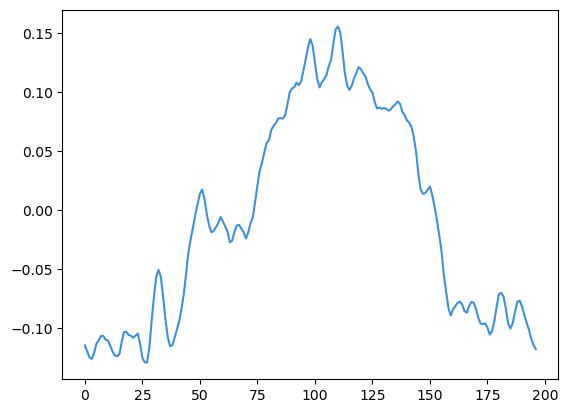

In [ ]:
plt.plot(r)